<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Full name, SCIPER number, email address  
- **Group member 2:** Full name, SCIPER number, email address  
- **Group member 3 (if applicable):** Full name, SCIPER number, email address  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [ ]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch

In [2]:
#File paths
dir_ = '/shared/NX-414/data/'
filename_NSD = 'nsd_func1pt8mm_individualROIs.h5'
filename_EEG = 'things_eeg2.h5'
filename_ephys = 'tvsd.h5'

# Utility Functions
# To inspect h5 files
def inspect_h5(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"Group: {name}")


In [3]:
#inspect fMRI data
filepath_NSD = f"{dir_}{filename_NSD}"

with h5py.File(filepath_NSD, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {filename_NSD}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
ROI_mapping: {"early": ["early"], "midventral": ["midventral"], "midlateral": ["midlateral"], "midparietal": ["midparietal"], "ventral": ["ventral"], "lateral": ["lateral"], "parietal": ["parietal"], "V1v": ["V1v"], "V1d": ["V1d"], "V2v": ["V2v"], "V2d": ["V2d"], "V3v": ["V3v"], "V3d": ["V3d"], "hV4": ["hV4"], "nsdgeneral": ["nsdgeneral"], "OWFA": ["OWFA"], "VWFA-1": ["VWFA-1"], "VWFA-2": ["VWFA-2"], "OPA": ["OPA"], "PPA": ["PPA"], "RSC": ["RSC"], "OFA": ["OFA"], "FFA-1": ["FFA-1"], "FFA-2": ["FFA-2"], "EBA": ["EBA"], "FBA-1": ["FBA-1"], "FBA-2": ["FBA-2"], "whole_brain": ["whole_brain"]}
beta_type: betas_fithrf_GLMdenoise_RR
data_space: func1pt8mm
dtype: float32
last_args: {"subject": "8", "data_space": "func1pt8mm", "beta_type": "betas_fithrf_GLMdenoise_RR", "ds_dir": "/mnt/scratch/akgokce/datasets/neural/nsd", "stim_csv_path": "/mnt/scratch/akgokce/brain/repos/data-driven-alignment/extract_n_eval/data/nsd_stim_mapping.csv", "roi_mapping": "individual", "nc_th

In [5]:
#inspect EEG data
filepath_EEG = f"{dir_}{filename_EEG}"

with h5py.File(filepath_EEG, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {filename_NSD}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
channels: ['Fp1' 'F3' 'F7' 'FT9' 'FC5' 'FC1' 'C3' 'T7' 'TP9' 'CP5' 'CP1' 'Pz' 'P3'
 'P7' 'O1' 'Oz' 'O2' 'P4' 'P8' 'TP10' 'CP6' 'CP2' 'Cz' 'C4' 'T8' 'FT10'
 'FC6' 'FC2' 'F4' 'F8' 'Fp2' 'AF7' 'AF3' 'AFz' 'F1' 'F5' 'FT7' 'FC3' 'FCz'
 'C1' 'C5' 'TP7' 'CP3' 'P1' 'P5' 'PO7' 'PO3' 'POz' 'PO4' 'PO8' 'P6' 'P2'
 'CPz' 'CP4' 'TP8' 'C6' 'C2' 'FC4' 'FT8' 'F6' 'F2' 'AF4' 'AF8']
max_nc: 100
metadata: {
  "desc": "\n    The neural data is from the THINGS EEG 2, recorded from 10 humans.\n    All neural data is averaged across trials for each image.\n    The neural data is concatenated across subjects and channels.\n    "
}
rois: ['occipital' 'parietal' 'temporal' 'frontal' 'central'
 'occipital_parietal' 'whole_brain']
splits: ['train' 'test']
subjects: ['sub-01' 'sub-02' 'sub-03' 'sub-04' 'sub-05' 'sub-06' 'sub-07' 'sub-08'
 'sub-09' 'sub-10']
time_points: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0

In [7]:
#inspect ephys data
filepath_ephys = f"{dir_}{filename_ephys}"

with h5py.File(filepath_ephys, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {filename_NSD}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
max_nc: 100
metadata: {
  "reliability": 0.1,
  "channel2region": {
    "monkeyN": {
      "V1": [
        0,
        511
      ],
      "V4": [
        512,
        767
      ],
      "IT": [
        768,
        1023
      ]
    },
    "monkeyF": {
      "V1": [
        0,
        511
      ],
      "V4": [
        832,
        1023
      ],
      "IT": [
        512,
        831
      ]
    }
  },
  "desc": "\n    The neural data is from the THINGS dataset, recorded from two monkeys (monkeyN and monkeyF).\n    The neural data is recorded from V1, V4, and IT regions.\n    The dataset includes both training and test splits.\n    Channels with reliability less than 0.1 are excluded.\n    "
}
rois: ['V1' 'V4' 'IT']
splits: ['train' 'test']
subjects: ['monkeyN' 'monkeyF']
Inspecting structure of: nsd_func1pt8mm_individualROIs.h5
----------------------------------------
Group: noise_ceilings
Group: noise_ceilings/monkeyF
Dataset: noise_ceilings/monkeyF/IT | Shape: 

---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [ ]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [ ]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [ ]:
import numpy as np


def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """

    ### TODO
    pass


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    ### TODO
    pass

In [ ]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [ ]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [ ]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

NOT USE SKLEARN, USES CLOSED FORM SOLVER                        
PREFER PYTORCH

### Starter code

In [1]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, pearsonr

from typing import Literal
import numpy as np

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        # Ensure both matrices have the same number of stimuli/conditions
        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"X and Y must have the same number of conditions (rows). "
                f"Got X: {X.shape[0]}, Y: {Y.shape[0]}"
            )
            
        # 1. Compute RDMs for both spaces
        rdm_x = self.compute_rdm(X)
        rdm_y = self.compute_rdm(Y)
        
        # 2. Compare the two RDMs
        return self.compare_rdms(rdm_x, rdm_y)

        
    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        # Flatten any spatial/temporal dimensions, keeping n_conditions as the first axis
        X_flat = X.reshape(X.shape[0], -1)
        
        # pdist computes the pairwise distances; squareform converts it to a symmetric matrix
        condensed_distance = pdist(X_flat, metric=self.dissimilarity)
        rdm = squareform(condensed_distance)
        
        return rdm
    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        # Extract indices for the upper triangle, excluding the diagonal (k=1)
        row_idx, col_idx = np.triu_indices(rdm1.shape[0], k=1)
        
        # Vectorize the upper triangles
        vec1 = rdm1[row_idx, col_idx]
        vec2 = rdm2[row_idx, col_idx]
        
        # Compute the specified correlation metric
        if self.similarity_metric == "spearman":
            correlation, _ = spearmanr(vec1, vec2)
        elif self.similarity_metric == "pearson":
            correlation, _ = pearsonr(vec1, vec2)
        else:
            raise ValueError(f"Unsupported similarity metric: {self.similarity_metric}")
            
        return float(correlation)

## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [2]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype  

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        n = X.shape[0]
        if n <= 3:
            raise ValueError("Unbiased HSIC requires at least 4 samples (n > 3).")

        # Form linear Gram matrices
        K = X @ X.T
        L = Y @ Y.T

        # Set diagonals to zero to remove the bias term
        np.fill_diagonal(K, 0)
        np.fill_diagonal(L, 0)

        # Calculate the three terms of the unbiased HSIC estimator
        # 1. Trace of product: tr(K L)
        term1 = np.sum(K * L) 
        
        # 2. Product of sums: (1^T K 1 * 1^T L 1) / ((n-1)*(n-2))
        term2 = (np.sum(K) * np.sum(L)) / ((n - 1) * (n - 2))
        
        # 3. Dot product of row sums: (1^T K L 1) / (n-2)
        term3 = 2 * np.dot(np.sum(K, axis=1), np.sum(L, axis=1)) / (n - 2)

        hsic = (term1 + term2 - term3) / (n * (n - 3))
        
        return hsic

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        hsic_xy = self._unbiased_linear_hsic(X, Y)
        hsic_xx = self._unbiased_linear_hsic(X, X)
        hsic_yy = self._unbiased_linear_hsic(Y, Y)

        # Bound the denominator components at 0 to avoid NaNs from floating point
        # inaccuracies in edge cases where HSIC(X,X) might be infinitesimally negative.
        denom = np.sqrt(max(hsic_xx * hsic_yy, 0.0)) + self.eps
        
        return hsic_xy / denom

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [ ]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

In [ ]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [ ]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

Using device: cuda
TVSD  — monkeyF/V1 | train=(22248, 462), test=(100, 462)
  NC: shape=(462,)  min=77.462  max=99.544  mean=94.282  n_above_thr(10.0)=462/462
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN — TVSD monkeyF/IT
Total jobs to run: 20  (TVSD × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/V1']

  ▶ Model A (ResNet)  (10 layers)
          ep   0  loss=9.612e+05  ||β||=0.00
          ep  50  loss=8.029e+05  ||β||=1.19
          ep 100  loss=5.839e+05  ||β||=1.22
          ep 150  loss=5.818e+05  ||β||=1.24
          ep 200  loss=5.817e+05  ||β||=1.25
          ep 250  loss=5.817e+05  ||β||=1.25
        α=1.0e+05  val_r=0.5300 ◀ best so far  (28.48s)
        Y_test  mean=-0.000  std=0.318
        Y_pred  mean=0.004  std=0.270
        Y_train mean=0.024  std=0.470
        Pearson r (mean over channels): 0.793
        EV       (mean over channels): 0.512
    [ 1/10] layer1-0                     V1  r=0.793  r_nc=0.

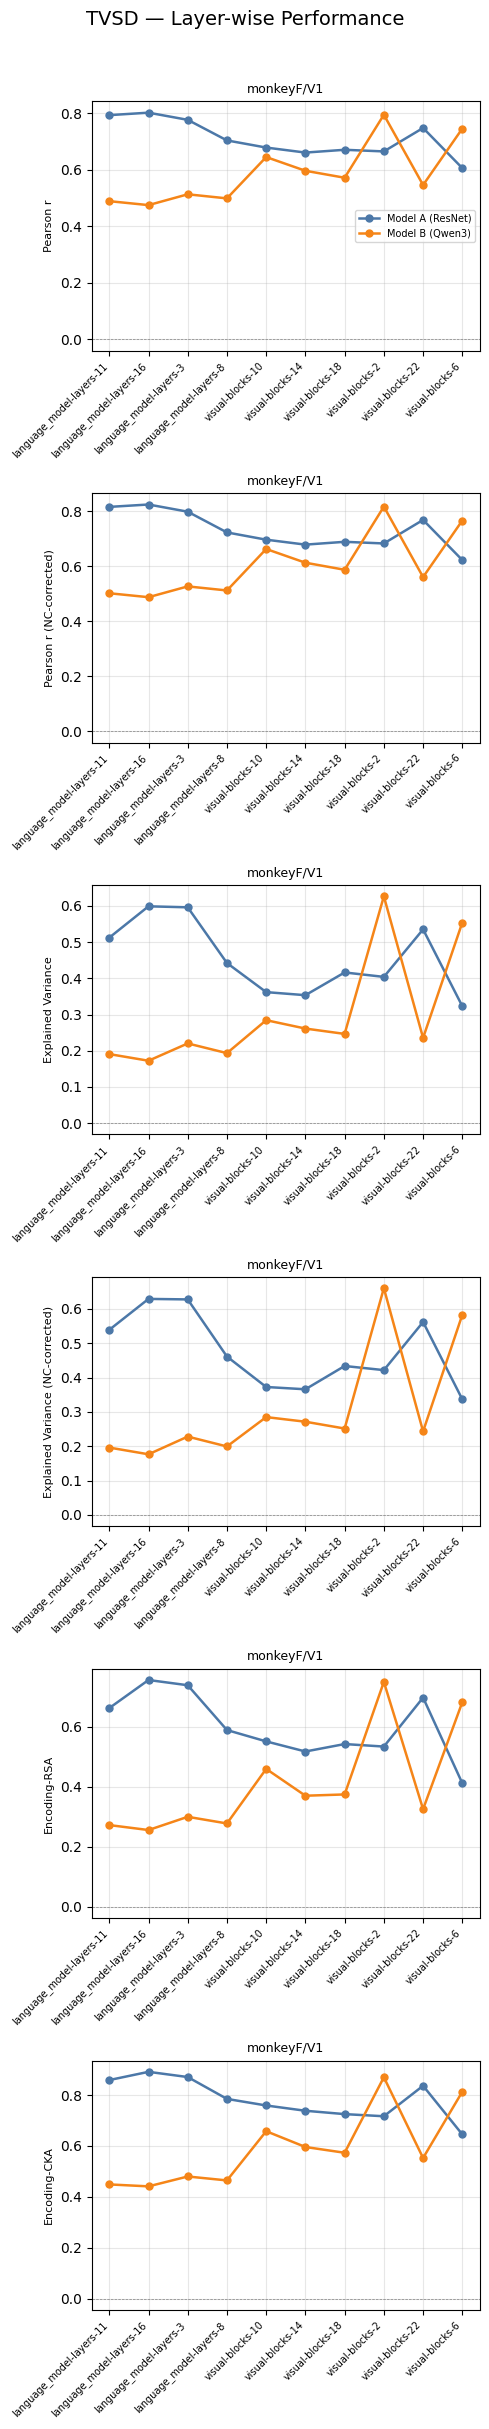

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,TVSD,Model A (ResNet),monkeyF/V1,layer2-0,0.802,0.825,0.599,0.629,0.755,0.891
1,TVSD,Model B (Qwen3),monkeyF/V1,visual-blocks-2,0.795,0.818,0.626,0.661,0.749,0.870


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,TVSD,monkeyF/V1,0.629,0.661,0.891,0.87,0.755,0.749,0.825,0.818


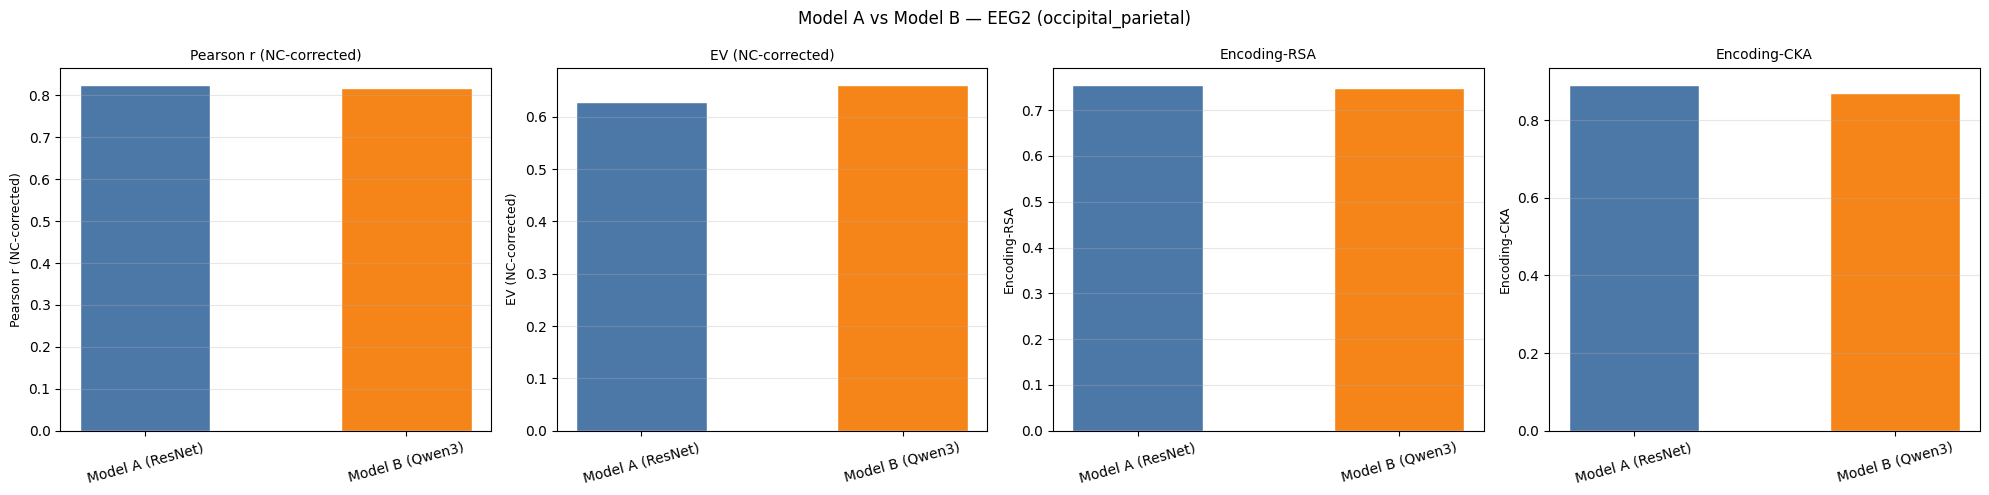


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [3]:
### WORKS:::: TVSD, monkeyF V1, ADAM??? 

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# (imports + DATA_DIR / FEAT_DIR / MODEL_A / MODEL_B / DEVICE same as before)

TVSD_MONKEY = "monkeyF"
TVSD_ROI    = "V1"
TVSD_TARGET = f"{TVSD_MONKEY}/{TVSD_ROI}"

# NC scaling — TVSD NC is in [0, 1], EEG was in [0, 100]
# NC_SCALE     = 1.0    # divisor used to bring NC into [0, 1]
# NC_THRESHOLD = 0.1    # mask threshold for "good enough" units (in raw NC units)

NC_SCALE     = 100.0   # ← change this
NC_THRESHOLD = 10.0    # ← and this (mask threshold in raw NC units)

# (list_h5_layers, h5_indexed_read, make_index_map, get_feat_indices unchanged)
def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

tvsd_ids = {}
tvsd_neural, tvsd_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    tvsd_neural[TVSD_TARGET] = {
        "train": f[f"train/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],  # (n_train, n_units)
        "test":  f[f"test/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],   # (n_test,  n_units)
    }
    tvsd_nc[TVSD_TARGET] = f[f"noise_ceilings/{TVSD_MONKEY}/{TVSD_ROI}"][:]  # (n_units,)

nc_flat = tvsd_nc[TVSD_TARGET]
print(f"TVSD  — {TVSD_TARGET} | "
      f"train={tvsd_neural[TVSD_TARGET]['train'].shape}, "
      f"test={tvsd_neural[TVSD_TARGET]['test'].shape}")
print(f"  NC: shape={nc_flat.shape}  min={nc_flat.min():.3f}  "
      f"max={nc_flat.max():.3f}  mean={nc_flat.mean():.3f}  "
      f"n_above_thr({NC_THRESHOLD})={int((nc_flat > NC_THRESHOLD).sum())}/{nc_flat.size}")
# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

# TVSD likely uses its own stimulus features file. Adjust if your FEAT_DIR uses
# things_stimuli.h5 for both datasets.
FEAT_FILE_TVSD = "things_stimuli.h5"

path_a_tvsd = os.path.join(FEAT_DIR, MODEL_A, FEAT_FILE_TVSD)
path_b_tvsd = os.path.join(FEAT_DIR, MODEL_B, FEAT_FILE_TVSD)

layers_a = list_h5_layers(path_a_tvsd)
layers_b = list_h5_layers(path_b_tvsd)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_tvsd_train = get_feat_indices(path_a_tvsd, tvsd_ids["train"])
feat_idx_tvsd_test  = get_feat_indices(path_a_tvsd, tvsd_ids["test"])
print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > NC_THRESHOLD
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }

def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

    nc_01 = nc_flat / NC_SCALE                                # ← was /100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary     = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42,
                       alpha_grid=None, n_epochs=300, lr=1e-3,
                       warm_start=True, verbose=True, **kwargs):
    """Iterative ridge via Adam. Memory ∝ X_train, not N² or D²."""
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr = torch.from_numpy(X_train[tr_idx].astype(np.float32)).to(DEVICE)
    Xvl = torch.from_numpy(X_train[val_idx].astype(np.float32)).to(DEVICE)
    Ytr = torch.from_numpy(Y_train[tr_idx].astype(np.float32)).to(DEVICE)
    Yvl_np = Y_train[val_idx].astype(np.float32)

    mean = Xtr.mean(0, keepdim=True)
    std  = Xtr.std(0, keepdim=True).clamp(min=1e-8)
    Xtr  = (Xtr - mean) / std
    Xvl  = (Xvl - mean) / std

    y_mean = Ytr.mean(0, keepdim=True)
    Ytr_c  = Ytr - y_mean

    D, C = Xtr.shape[1], Ytr.shape[1]

    best_alpha, best_score, best_beta = alpha_grid[0], -np.inf, None
    beta = torch.zeros(D, C, device=DEVICE, requires_grad=True)

    for alpha in alpha_grid:
        t0 = time.time()
        if not warm_start:
            beta = torch.zeros(D, C, device=DEVICE, requires_grad=True)
        opt = torch.optim.Adam([beta], lr=lr)

        for ep in range(n_epochs):
            opt.zero_grad()
            Y_pred = Xtr @ beta
            # sum-of-squares ridge loss → α range matches closed-form grid
            loss = 0.5 * ((Y_pred - Ytr_c) ** 2).sum() \
                 + 0.5 * float(alpha) * (beta ** 2).sum()
            if ep % 50 == 0:
                print(f"          ep {ep:3d}  loss={loss.item():.3e}  ||β||={beta.norm().item():.2f}")
            loss.backward()
            opt.step()

        with torch.no_grad():
            Yv_hat = (Xvl @ beta + y_mean).cpu().numpy()
        score = float(np.nanmean(pearson_r_per_unit(Yvl_np, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        if verbose:
            print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  "
                  f"({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha
            best_beta = beta.detach().clone()

    del Xtr, Xvl, Ytr, Ytr_c, beta
    torch.cuda.empty_cache()

    # Refit on full train (tr + val) at the chosen α, warm-start from best_beta
    X_full = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f = X_full.mean(0, keepdim=True)
    std_f  = X_full.std(0, keepdim=True).clamp(min=1e-8)
    X_full = (X_full - mean_f) / std_f

    Y_full   = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f = Y_full.mean(0, keepdim=True)
    Y_full_c = Y_full - y_mean_f

    beta_final = best_beta.clone().requires_grad_(True)
    opt = torch.optim.Adam([beta_final], lr=lr)
    for ep in range(n_epochs):
        opt.zero_grad()
        Y_pred = X_full @ beta_final
        loss = 0.5 * ((Y_pred - Y_full_c) ** 2).sum() \
             + 0.5 * float(best_alpha) * (beta_final ** 2).sum()
        loss.backward()
        opt.step()

    beta_out = beta_final.detach()
    del X_full, Y_full, Y_full_c, beta_final
    torch.cuda.empty_cache()

    return beta_out, mean_f, std_f, y_mean_f, best_alpha
# def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
#     X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
#     X_test_t = (X_test_t - mean) / std
#     with torch.no_grad():
#         Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

#     nc_01 = nc_flat / 100.0
#     r     = pearson_r_per_unit(Y_test, Y_pred)
#     ev    = explained_variance_per_unit(Y_test, Y_pred)
#     r_nc  = nc_correct_r(r, nc_01)
#     ev_nc = nc_correct_ev(ev, nc_01)

#     summary = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
#     per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
#     return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — TVSD monkeyF/IT")
    N_TRAIN, N_TEST = 18000, 200
    N_LAYERS        = None
    ALPHA_GRID_RUN  = np.logspace(4, 6, 3)

    tvsd_neural_run = {TVSD_TARGET: {
        "train": tvsd_neural[TVSD_TARGET]["train"][:N_TRAIN],
        "test":  tvsd_neural[TVSD_TARGET]["test"][:N_TEST],
    }}
    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
else:
    print("🚀 FULL RUN — TVSD monkeyF/IT")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(5, 5, 1)

    tvsd_neural_run    = tvsd_neural          # already {TVSD_TARGET: {...}}
    idx_tvsd_train_run = feat_idx_tvsd_train
    idx_tvsd_test_run  = feat_idx_tvsd_test

tvsd_nc_run = tvsd_nc                          # already {TVSD_TARGET: nc_flat}
# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("TVSD",
     path_a_tvsd, path_b_tvsd,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
]

total_jobs = len(list_h5_layers(path_a_tvsd)) * len(tvsd_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (TVSD × models × layers × targets)\n")

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred, per_channel = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)
                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":           ds_name,
                    "model":             model_name,
                    "layer":             layer,
                    "target":            target_key,
                    "alpha":             best_alpha,
                    **metrics,
                    "r_per_channel":     per_channel["r"],
                    "ev_per_channel":    per_channel["ev"],
                    "r_nc_per_channel":  per_channel["r_nc"],
                    "ev_nc_per_channel": per_channel["ev_nc"],
                    "encoding_rsa":      enc_rsa,
                    "encoding_cka":      enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()

# # ─────────────────────────────────────────────────────────────
# # CELL 2.4.5b  ·  Per-channel best-layer analysis
# # ─────────────────────────────────────────────────────────────
# import re
# from collections import Counter

# def natkey(s):
#     return [int(t) if t.isdigit() else t.lower()
#             for t in re.split(r"(\d+)", s)]

# for model_name in df_results["model"].unique():
#     sub = df_results[df_results["model"] == model_name].copy()
#     sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

#     R = np.stack(sub["r_per_channel"].values)      # (n_layers, n_channels)
#     layers = sub["layer"].values

#     best_idx   = R.argmax(axis=0)
#     best_layer = layers[best_idx]
#     best_r     = R[best_idx, np.arange(R.shape[1])]

#     print(f"\n=== {model_name} ===")
#     print(f"R matrix shape: {R.shape}  (layers × channels)")
#     for ch in range(R.shape[1]):
#         print(f"  ch {ch:2d}:  best={best_layer[ch].split('/')[-1]:<25} "
#               f"r={best_r[ch]:.3f}")

#     tally = Counter(best_layer)
#     print(f"\n  Channels per winning layer:")
#     for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
#         print(f"    {layer.split('/')[-1]:<25} {n} channel(s)")

#     # Heatmap
#     layer_labels = [l.split("/")[-1] for l in layers]
#     fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * R.shape[1])))
#     im = ax.imshow(R.T, aspect="auto", cmap="viridis")
#     ax.set_xticks(range(len(layer_labels)))
#     ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
#     ax.set_yticks(range(R.shape[1]))
#     ax.set_yticklabels([f"ch{i}" for i in range(R.shape[1])], fontsize=7)
#     ax.set_xlabel("Layer")
#     ax.set_ylabel("Channel")
#     ax.set_title(f"{model_name} — Pearson r per channel × layer")
#     plt.colorbar(im, ax=ax, label="r")
#     plt.tight_layout()
#     plt.show()

# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [5]:
df_results.to_csv("tvsd_monkeyf_v1_full_adam.csv", index=False)
df_results.to_pickle("tvsd_monkeyf_v1_full_adam.pkl")
# Reload with:
# df_results = pd.read_pickle("tvsd_encoding_results.pkl")

Using device: cuda
TVSD  — monkeyF/V4 | train=(22248, 139), test=(100, 139)
  NC: shape=(139,)  min=77.953  max=99.573  mean=96.191  n_above_thr(10.0)=139/139
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN — TVSD monkeyF/IT
Total jobs to run: 20  (TVSD × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/V4']

  ▶ Model A (ResNet)  (10 layers)
          ep   0  loss=3.081e+05  ||β||=0.00
          ep  50  loss=2.565e+05  ||β||=0.72
          ep 100  loss=2.053e+05  ||β||=0.71
          ep 150  loss=2.047e+05  ||β||=0.72
          ep 200  loss=2.047e+05  ||β||=0.72
          ep 250  loss=2.047e+05  ||β||=0.72
        α=1.0e+05  val_r=0.4412 ◀ best so far  (10.84s)
        Y_test  mean=0.000  std=0.394
        Y_pred  mean=0.010  std=0.246
        Y_train mean=0.014  std=0.485
        Pearson r (mean over channels): 0.596
        EV       (mean over channels): 0.329
    [ 1/10] layer1-0                     V4  r=0.596  r_nc=0.6

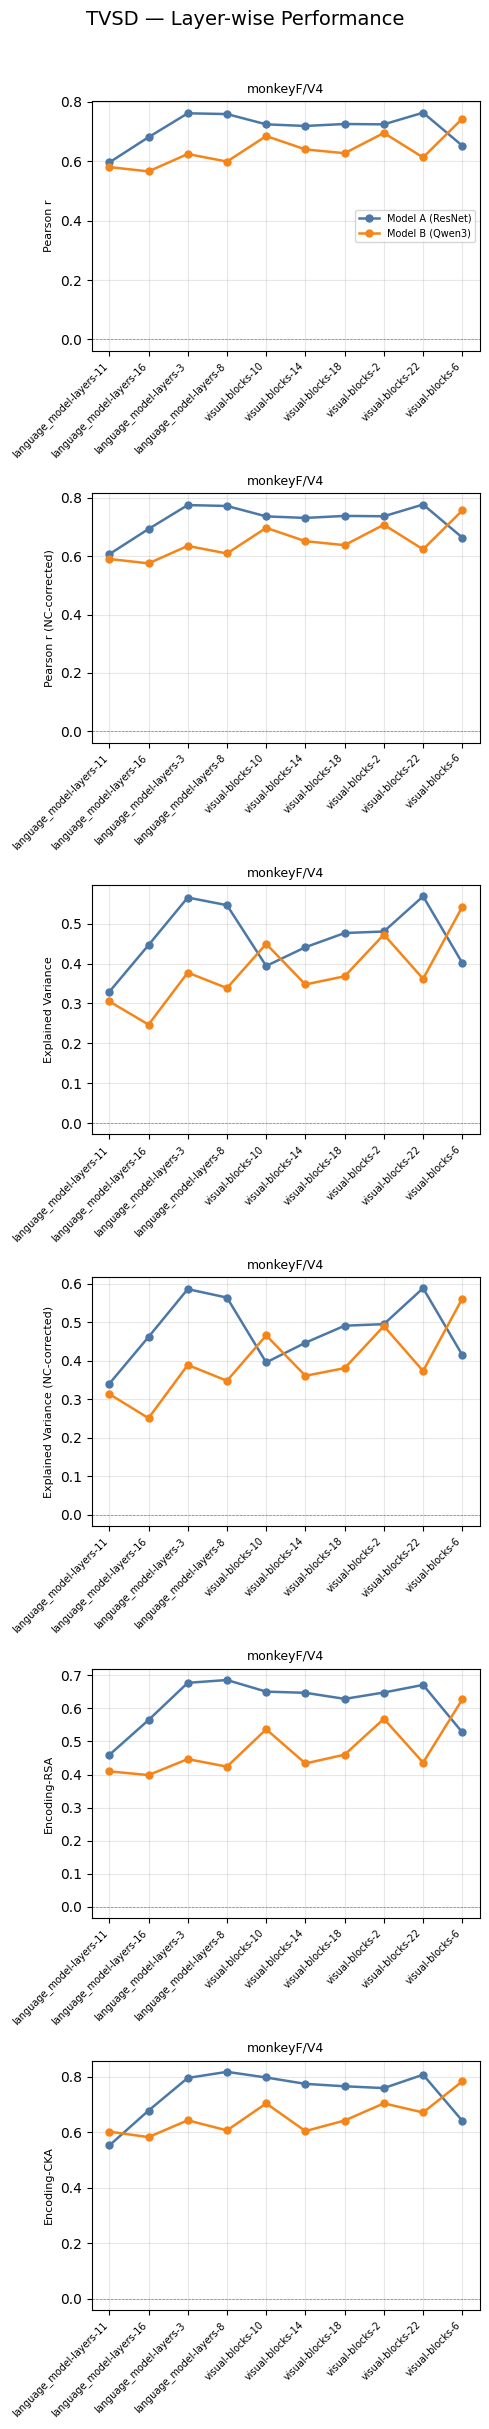

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,TVSD,Model A (ResNet),monkeyF/V4,layer3-5,0.763,0.778,0.568,0.588,0.671,0.807
1,TVSD,Model B (Qwen3),monkeyF/V4,visual-blocks-6,0.743,0.757,0.542,0.561,0.628,0.783


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,TVSD,monkeyF/V4,0.588,0.561,0.807,0.783,0.671,0.628,0.778,0.757


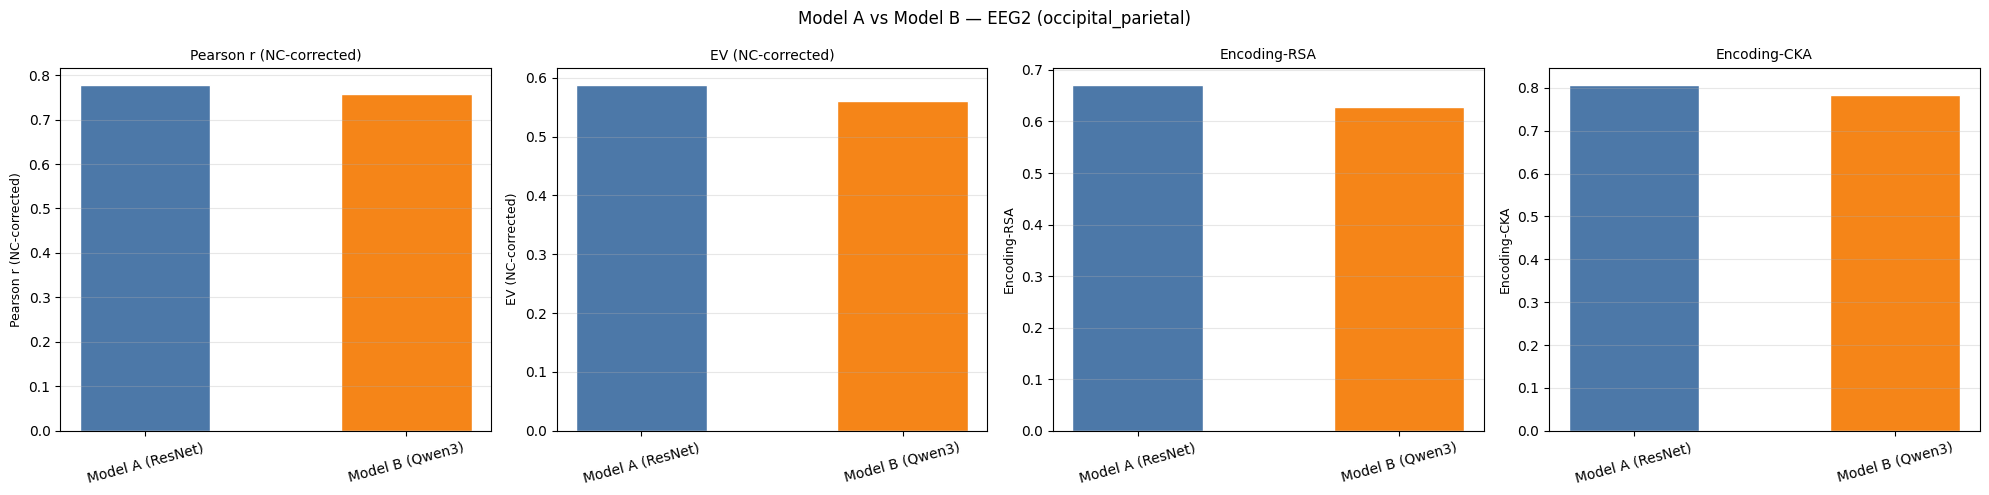


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [3]:
### TVSD, monkeyF V4, ADAM??? WORKS

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# (imports + DATA_DIR / FEAT_DIR / MODEL_A / MODEL_B / DEVICE same as before)

TVSD_MONKEY = "monkeyF"
TVSD_ROI    = "V4"
TVSD_TARGET = f"{TVSD_MONKEY}/{TVSD_ROI}"

# NC scaling — TVSD NC is in [0, 1], EEG was in [0, 100]
# NC_SCALE     = 1.0    # divisor used to bring NC into [0, 1]
# NC_THRESHOLD = 0.1    # mask threshold for "good enough" units (in raw NC units)

NC_SCALE     = 100.0   # ← change this
NC_THRESHOLD = 10.0    # ← and this (mask threshold in raw NC units)

# (list_h5_layers, h5_indexed_read, make_index_map, get_feat_indices unchanged)
def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

tvsd_ids = {}
tvsd_neural, tvsd_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    tvsd_neural[TVSD_TARGET] = {
        "train": f[f"train/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],  # (n_train, n_units)
        "test":  f[f"test/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],   # (n_test,  n_units)
    }
    tvsd_nc[TVSD_TARGET] = f[f"noise_ceilings/{TVSD_MONKEY}/{TVSD_ROI}"][:]  # (n_units,)

nc_flat = tvsd_nc[TVSD_TARGET]
print(f"TVSD  — {TVSD_TARGET} | "
      f"train={tvsd_neural[TVSD_TARGET]['train'].shape}, "
      f"test={tvsd_neural[TVSD_TARGET]['test'].shape}")
print(f"  NC: shape={nc_flat.shape}  min={nc_flat.min():.3f}  "
      f"max={nc_flat.max():.3f}  mean={nc_flat.mean():.3f}  "
      f"n_above_thr({NC_THRESHOLD})={int((nc_flat > NC_THRESHOLD).sum())}/{nc_flat.size}")
# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

# TVSD likely uses its own stimulus features file. Adjust if your FEAT_DIR uses
# things_stimuli.h5 for both datasets.
FEAT_FILE_TVSD = "things_stimuli.h5"

path_a_tvsd = os.path.join(FEAT_DIR, MODEL_A, FEAT_FILE_TVSD)
path_b_tvsd = os.path.join(FEAT_DIR, MODEL_B, FEAT_FILE_TVSD)

layers_a = list_h5_layers(path_a_tvsd)
layers_b = list_h5_layers(path_b_tvsd)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_tvsd_train = get_feat_indices(path_a_tvsd, tvsd_ids["train"])
feat_idx_tvsd_test  = get_feat_indices(path_a_tvsd, tvsd_ids["test"])
print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > NC_THRESHOLD
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }

def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

    nc_01 = nc_flat / NC_SCALE                                # ← was /100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary     = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42,
                       alpha_grid=None, n_epochs=300, lr=1e-3,
                       warm_start=True, verbose=True, **kwargs):
    """Iterative ridge via Adam. Memory ∝ X_train, not N² or D²."""
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr = torch.from_numpy(X_train[tr_idx].astype(np.float32)).to(DEVICE)
    Xvl = torch.from_numpy(X_train[val_idx].astype(np.float32)).to(DEVICE)
    Ytr = torch.from_numpy(Y_train[tr_idx].astype(np.float32)).to(DEVICE)
    Yvl_np = Y_train[val_idx].astype(np.float32)

    mean = Xtr.mean(0, keepdim=True)
    std  = Xtr.std(0, keepdim=True).clamp(min=1e-8)
    Xtr  = (Xtr - mean) / std
    Xvl  = (Xvl - mean) / std

    y_mean = Ytr.mean(0, keepdim=True)
    Ytr_c  = Ytr - y_mean

    D, C = Xtr.shape[1], Ytr.shape[1]

    best_alpha, best_score, best_beta = alpha_grid[0], -np.inf, None
    beta = torch.zeros(D, C, device=DEVICE, requires_grad=True)

    for alpha in alpha_grid:
        t0 = time.time()
        if not warm_start:
            beta = torch.zeros(D, C, device=DEVICE, requires_grad=True)
        opt = torch.optim.Adam([beta], lr=lr)

        for ep in range(n_epochs):
            opt.zero_grad()
            Y_pred = Xtr @ beta
            # sum-of-squares ridge loss → α range matches closed-form grid
            loss = 0.5 * ((Y_pred - Ytr_c) ** 2).sum() \
                 + 0.5 * float(alpha) * (beta ** 2).sum()
            if ep % 50 == 0:
                print(f"          ep {ep:3d}  loss={loss.item():.3e}  ||β||={beta.norm().item():.2f}")
            loss.backward()
            opt.step()

        with torch.no_grad():
            Yv_hat = (Xvl @ beta + y_mean).cpu().numpy()
        score = float(np.nanmean(pearson_r_per_unit(Yvl_np, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        if verbose:
            print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  "
                  f"({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha
            best_beta = beta.detach().clone()

    del Xtr, Xvl, Ytr, Ytr_c, beta
    torch.cuda.empty_cache()

    # Refit on full train (tr + val) at the chosen α, warm-start from best_beta
    X_full = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f = X_full.mean(0, keepdim=True)
    std_f  = X_full.std(0, keepdim=True).clamp(min=1e-8)
    X_full = (X_full - mean_f) / std_f

    Y_full   = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f = Y_full.mean(0, keepdim=True)
    Y_full_c = Y_full - y_mean_f

    beta_final = best_beta.clone().requires_grad_(True)
    opt = torch.optim.Adam([beta_final], lr=lr)
    for ep in range(n_epochs):
        opt.zero_grad()
        Y_pred = X_full @ beta_final
        loss = 0.5 * ((Y_pred - Y_full_c) ** 2).sum() \
             + 0.5 * float(best_alpha) * (beta_final ** 2).sum()
        loss.backward()
        opt.step()

    beta_out = beta_final.detach()
    del X_full, Y_full, Y_full_c, beta_final
    torch.cuda.empty_cache()

    return beta_out, mean_f, std_f, y_mean_f, best_alpha
# def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
#     X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
#     X_test_t = (X_test_t - mean) / std
#     with torch.no_grad():
#         Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

#     nc_01 = nc_flat / 100.0
#     r     = pearson_r_per_unit(Y_test, Y_pred)
#     ev    = explained_variance_per_unit(Y_test, Y_pred)
#     r_nc  = nc_correct_r(r, nc_01)
#     ev_nc = nc_correct_ev(ev, nc_01)

#     summary = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
#     per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
#     return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — TVSD monkeyF/IT")
    N_TRAIN, N_TEST = 18000, 200
    N_LAYERS        = None
    ALPHA_GRID_RUN  = np.logspace(4, 6, 3)

    tvsd_neural_run = {TVSD_TARGET: {
        "train": tvsd_neural[TVSD_TARGET]["train"][:N_TRAIN],
        "test":  tvsd_neural[TVSD_TARGET]["test"][:N_TEST],
    }}
    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
else:
    print("🚀 FULL RUN — TVSD monkeyF/IT")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(5, 5, 1)

    tvsd_neural_run    = tvsd_neural          # already {TVSD_TARGET: {...}}
    idx_tvsd_train_run = feat_idx_tvsd_train
    idx_tvsd_test_run  = feat_idx_tvsd_test

tvsd_nc_run = tvsd_nc                          # already {TVSD_TARGET: nc_flat}
# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("TVSD",
     path_a_tvsd, path_b_tvsd,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
]

total_jobs = len(list_h5_layers(path_a_tvsd)) * len(tvsd_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (TVSD × models × layers × targets)\n")

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred, per_channel = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)
                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":           ds_name,
                    "model":             model_name,
                    "layer":             layer,
                    "target":            target_key,
                    "alpha":             best_alpha,
                    **metrics,
                    "r_per_channel":     per_channel["r"],
                    "ev_per_channel":    per_channel["ev"],
                    "r_nc_per_channel":  per_channel["r_nc"],
                    "ev_nc_per_channel": per_channel["ev_nc"],
                    "encoding_rsa":      enc_rsa,
                    "encoding_cka":      enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()

# # ─────────────────────────────────────────────────────────────
# # CELL 2.4.5b  ·  Per-channel best-layer analysis
# # ─────────────────────────────────────────────────────────────
# import re
# from collections import Counter

# def natkey(s):
#     return [int(t) if t.isdigit() else t.lower()
#             for t in re.split(r"(\d+)", s)]

# for model_name in df_results["model"].unique():
#     sub = df_results[df_results["model"] == model_name].copy()
#     sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

#     R = np.stack(sub["r_per_channel"].values)      # (n_layers, n_channels)
#     layers = sub["layer"].values

#     best_idx   = R.argmax(axis=0)
#     best_layer = layers[best_idx]
#     best_r     = R[best_idx, np.arange(R.shape[1])]

#     print(f"\n=== {model_name} ===")
#     print(f"R matrix shape: {R.shape}  (layers × channels)")
#     for ch in range(R.shape[1]):
#         print(f"  ch {ch:2d}:  best={best_layer[ch].split('/')[-1]:<25} "
#               f"r={best_r[ch]:.3f}")

#     tally = Counter(best_layer)
#     print(f"\n  Channels per winning layer:")
#     for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
#         print(f"    {layer.split('/')[-1]:<25} {n} channel(s)")

#     # Heatmap
#     layer_labels = [l.split("/")[-1] for l in layers]
#     fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * R.shape[1])))
#     im = ax.imshow(R.T, aspect="auto", cmap="viridis")
#     ax.set_xticks(range(len(layer_labels)))
#     ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
#     ax.set_yticks(range(R.shape[1]))
#     ax.set_yticklabels([f"ch{i}" for i in range(R.shape[1])], fontsize=7)
#     ax.set_xlabel("Layer")
#     ax.set_ylabel("Channel")
#     ax.set_title(f"{model_name} — Pearson r per channel × layer")
#     plt.colorbar(im, ax=ax, label="r")
#     plt.tight_layout()
#     plt.show()

# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [4]:
df_results.to_csv("tvsd_monkeyf_v4_full_adam.csv", index=False)
df_results.to_pickle("tvsd_monkeyf_v4_full_adam.pkl")
# Reload with:
# df_results = pd.read_pickle("tvsd_encoding_results.pkl")

Using device: cuda
TVSD  — monkeyF/IT | train=(22248, 241), test=(100, 241)
  NC: shape=(241,)  min=77.246  max=99.287  mean=93.037  n_above_thr(10.0)=241/241
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN — TVSD monkeyF/IT
Total jobs to run: 20  (TVSD × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/IT']

  ▶ Model A (ResNet)  (10 layers)
          ep   0  loss=3.779e+05  ||β||=0.00
          ep  50  loss=3.782e+05  ||β||=0.78
          ep 100  loss=2.926e+05  ||β||=0.75
          ep 150  loss=2.919e+05  ||β||=0.76
          ep 200  loss=2.919e+05  ||β||=0.76
          ep 250  loss=2.946e+05  ||β||=0.76
        α=1.0e+05  val_r=0.3094 ◀ best so far  (14.56s)
        Y_test  mean=-0.000  std=0.272
        Y_pred  mean=0.027  std=0.162
        Y_train mean=0.025  std=0.408
        Pearson r (mean over channels): 0.471
        EV       (mean over channels): 0.149
    [ 1/10] layer1-0                     IT  r=0.471  r_nc=0.

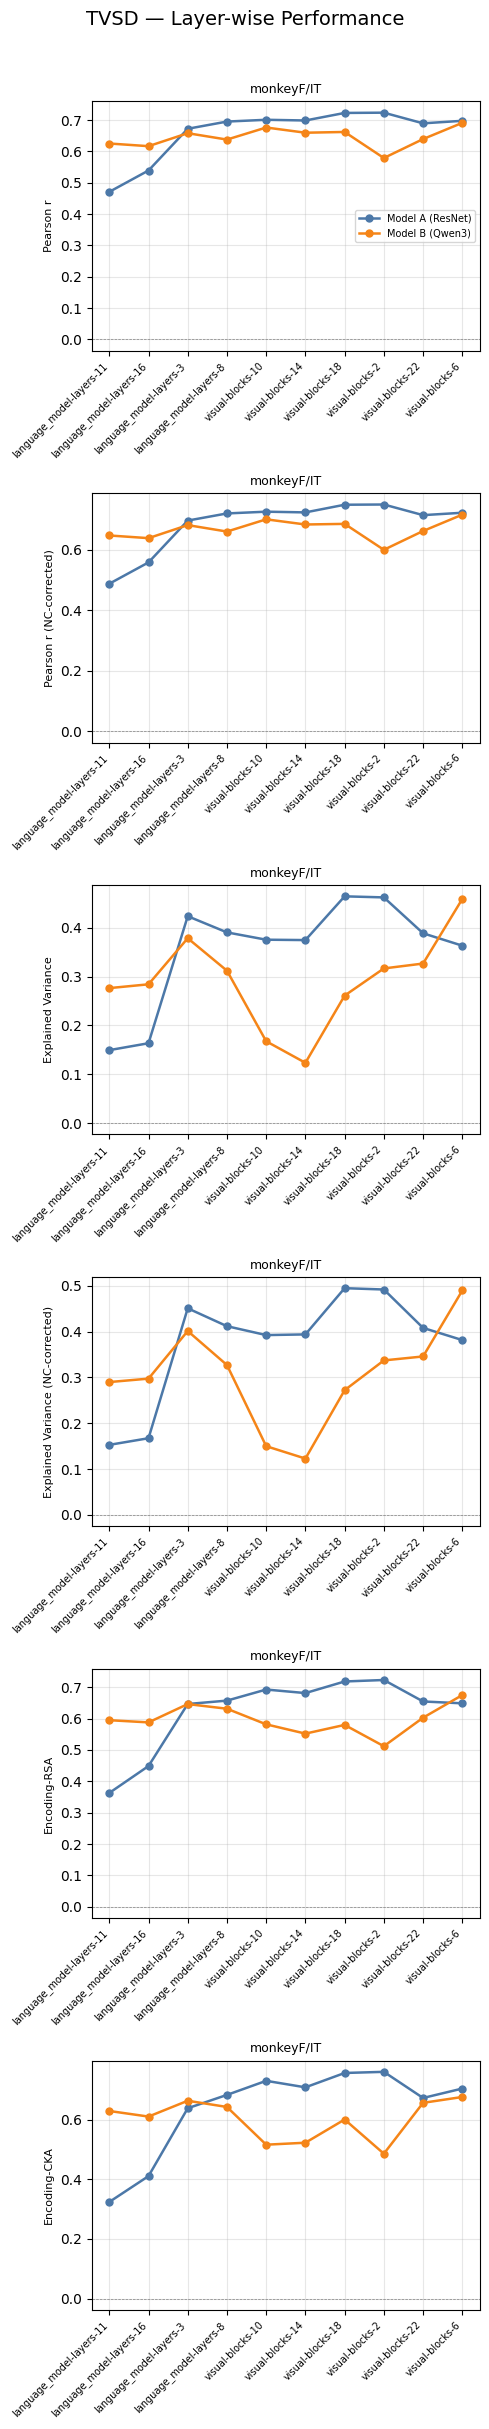

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,TVSD,Model A (ResNet),monkeyF/IT,layer3-30,0.724,0.750,0.462,0.492,0.723,0.760
1,TVSD,Model B (Qwen3),monkeyF/IT,visual-blocks-6,0.691,0.716,0.459,0.490,0.675,0.676


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,TVSD,monkeyF/IT,0.492,0.49,0.76,0.676,0.723,0.675,0.75,0.716


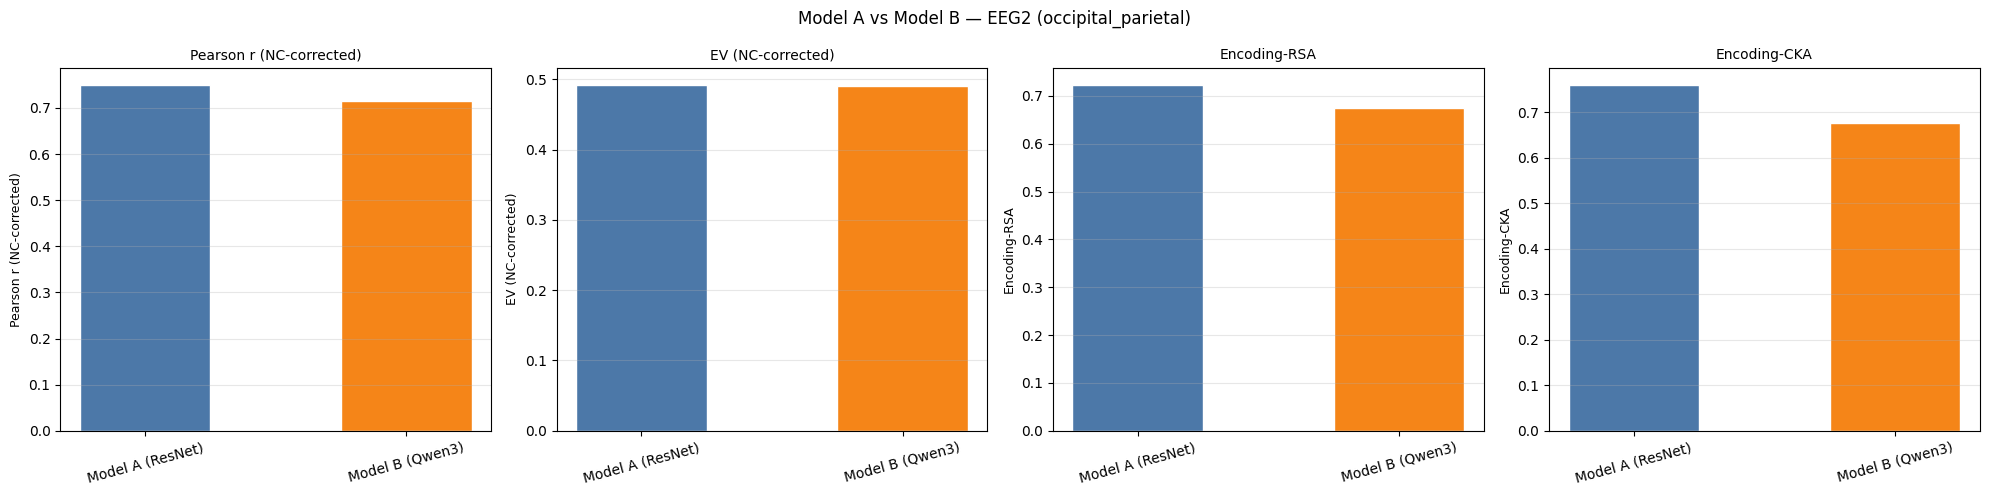


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [3]:
### TVSD, monkeyF IT, ADAM??? WORKS

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# (imports + DATA_DIR / FEAT_DIR / MODEL_A / MODEL_B / DEVICE same as before)

TVSD_MONKEY = "monkeyF"
TVSD_ROI    = "IT"
TVSD_TARGET = f"{TVSD_MONKEY}/{TVSD_ROI}"

# NC scaling — TVSD NC is in [0, 1], EEG was in [0, 100]
# NC_SCALE     = 1.0    # divisor used to bring NC into [0, 1]
# NC_THRESHOLD = 0.1    # mask threshold for "good enough" units (in raw NC units)

NC_SCALE     = 100.0   # ← change this
NC_THRESHOLD = 10.0    # ← and this (mask threshold in raw NC units)

# (list_h5_layers, h5_indexed_read, make_index_map, get_feat_indices unchanged)
def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

tvsd_ids = {}
tvsd_neural, tvsd_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    tvsd_neural[TVSD_TARGET] = {
        "train": f[f"train/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],  # (n_train, n_units)
        "test":  f[f"test/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],   # (n_test,  n_units)
    }
    tvsd_nc[TVSD_TARGET] = f[f"noise_ceilings/{TVSD_MONKEY}/{TVSD_ROI}"][:]  # (n_units,)

nc_flat = tvsd_nc[TVSD_TARGET]
print(f"TVSD  — {TVSD_TARGET} | "
      f"train={tvsd_neural[TVSD_TARGET]['train'].shape}, "
      f"test={tvsd_neural[TVSD_TARGET]['test'].shape}")
print(f"  NC: shape={nc_flat.shape}  min={nc_flat.min():.3f}  "
      f"max={nc_flat.max():.3f}  mean={nc_flat.mean():.3f}  "
      f"n_above_thr({NC_THRESHOLD})={int((nc_flat > NC_THRESHOLD).sum())}/{nc_flat.size}")
# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

# TVSD likely uses its own stimulus features file. Adjust if your FEAT_DIR uses
# things_stimuli.h5 for both datasets.
FEAT_FILE_TVSD = "things_stimuli.h5"

path_a_tvsd = os.path.join(FEAT_DIR, MODEL_A, FEAT_FILE_TVSD)
path_b_tvsd = os.path.join(FEAT_DIR, MODEL_B, FEAT_FILE_TVSD)

layers_a = list_h5_layers(path_a_tvsd)
layers_b = list_h5_layers(path_b_tvsd)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_tvsd_train = get_feat_indices(path_a_tvsd, tvsd_ids["train"])
feat_idx_tvsd_test  = get_feat_indices(path_a_tvsd, tvsd_ids["test"])
print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > NC_THRESHOLD
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }

def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

    nc_01 = nc_flat / NC_SCALE                                # ← was /100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary     = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42,
                       alpha_grid=None, n_epochs=300, lr=1e-3,
                       warm_start=True, verbose=True, **kwargs):
    """Iterative ridge via Adam. Memory ∝ X_train, not N² or D²."""
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr = torch.from_numpy(X_train[tr_idx].astype(np.float32)).to(DEVICE)
    Xvl = torch.from_numpy(X_train[val_idx].astype(np.float32)).to(DEVICE)
    Ytr = torch.from_numpy(Y_train[tr_idx].astype(np.float32)).to(DEVICE)
    Yvl_np = Y_train[val_idx].astype(np.float32)

    mean = Xtr.mean(0, keepdim=True)
    std  = Xtr.std(0, keepdim=True).clamp(min=1e-8)
    Xtr  = (Xtr - mean) / std
    Xvl  = (Xvl - mean) / std

    y_mean = Ytr.mean(0, keepdim=True)
    Ytr_c  = Ytr - y_mean

    D, C = Xtr.shape[1], Ytr.shape[1]

    best_alpha, best_score, best_beta = alpha_grid[0], -np.inf, None
    beta = torch.zeros(D, C, device=DEVICE, requires_grad=True)

    for alpha in alpha_grid:
        t0 = time.time()
        if not warm_start:
            beta = torch.zeros(D, C, device=DEVICE, requires_grad=True)
        opt = torch.optim.Adam([beta], lr=lr)

        for ep in range(n_epochs):
            opt.zero_grad()
            Y_pred = Xtr @ beta
            # sum-of-squares ridge loss → α range matches closed-form grid
            loss = 0.5 * ((Y_pred - Ytr_c) ** 2).sum() \
                 + 0.5 * float(alpha) * (beta ** 2).sum()
            if ep % 50 == 0:
                print(f"          ep {ep:3d}  loss={loss.item():.3e}  ||β||={beta.norm().item():.2f}")
            loss.backward()
            opt.step()

        with torch.no_grad():
            Yv_hat = (Xvl @ beta + y_mean).cpu().numpy()
        score = float(np.nanmean(pearson_r_per_unit(Yvl_np, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        if verbose:
            print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  "
                  f"({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha
            best_beta = beta.detach().clone()

    del Xtr, Xvl, Ytr, Ytr_c, beta
    torch.cuda.empty_cache()

    # Refit on full train (tr + val) at the chosen α, warm-start from best_beta
    X_full = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f = X_full.mean(0, keepdim=True)
    std_f  = X_full.std(0, keepdim=True).clamp(min=1e-8)
    X_full = (X_full - mean_f) / std_f

    Y_full   = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f = Y_full.mean(0, keepdim=True)
    Y_full_c = Y_full - y_mean_f

    beta_final = best_beta.clone().requires_grad_(True)
    opt = torch.optim.Adam([beta_final], lr=lr)
    for ep in range(n_epochs):
        opt.zero_grad()
        Y_pred = X_full @ beta_final
        loss = 0.5 * ((Y_pred - Y_full_c) ** 2).sum() \
             + 0.5 * float(best_alpha) * (beta_final ** 2).sum()
        loss.backward()
        opt.step()

    beta_out = beta_final.detach()
    del X_full, Y_full, Y_full_c, beta_final
    torch.cuda.empty_cache()

    return beta_out, mean_f, std_f, y_mean_f, best_alpha
# def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
#     X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
#     X_test_t = (X_test_t - mean) / std
#     with torch.no_grad():
#         Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

#     nc_01 = nc_flat / 100.0
#     r     = pearson_r_per_unit(Y_test, Y_pred)
#     ev    = explained_variance_per_unit(Y_test, Y_pred)
#     r_nc  = nc_correct_r(r, nc_01)
#     ev_nc = nc_correct_ev(ev, nc_01)

#     summary = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
#     per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
#     return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — TVSD monkeyF/IT")
    N_TRAIN, N_TEST = 18000, 200
    N_LAYERS        = None
    ALPHA_GRID_RUN  = np.logspace(5, 7, 3)

    tvsd_neural_run = {TVSD_TARGET: {
        "train": tvsd_neural[TVSD_TARGET]["train"][:N_TRAIN],
        "test":  tvsd_neural[TVSD_TARGET]["test"][:N_TEST],
    }}
    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
else:
    print("🚀 FULL RUN — TVSD monkeyF/IT")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(5, 5, 1)

    tvsd_neural_run    = tvsd_neural          # already {TVSD_TARGET: {...}}
    idx_tvsd_train_run = feat_idx_tvsd_train
    idx_tvsd_test_run  = feat_idx_tvsd_test

tvsd_nc_run = tvsd_nc                          # already {TVSD_TARGET: nc_flat}
# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("TVSD",
     path_a_tvsd, path_b_tvsd,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
]

total_jobs = len(list_h5_layers(path_a_tvsd)) * len(tvsd_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (TVSD × models × layers × targets)\n")

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred, per_channel = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)
                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":           ds_name,
                    "model":             model_name,
                    "layer":             layer,
                    "target":            target_key,
                    "alpha":             best_alpha,
                    **metrics,
                    "r_per_channel":     per_channel["r"],
                    "ev_per_channel":    per_channel["ev"],
                    "r_nc_per_channel":  per_channel["r_nc"],
                    "ev_nc_per_channel": per_channel["ev_nc"],
                    "encoding_rsa":      enc_rsa,
                    "encoding_cka":      enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()

# # ─────────────────────────────────────────────────────────────
# # CELL 2.4.5b  ·  Per-channel best-layer analysis
# # ─────────────────────────────────────────────────────────────
# import re
# from collections import Counter

# def natkey(s):
#     return [int(t) if t.isdigit() else t.lower()
#             for t in re.split(r"(\d+)", s)]

# for model_name in df_results["model"].unique():
#     sub = df_results[df_results["model"] == model_name].copy()
#     sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

#     R = np.stack(sub["r_per_channel"].values)      # (n_layers, n_channels)
#     layers = sub["layer"].values

#     best_idx   = R.argmax(axis=0)
#     best_layer = layers[best_idx]
#     best_r     = R[best_idx, np.arange(R.shape[1])]

#     print(f"\n=== {model_name} ===")
#     print(f"R matrix shape: {R.shape}  (layers × channels)")
#     for ch in range(R.shape[1]):
#         print(f"  ch {ch:2d}:  best={best_layer[ch].split('/')[-1]:<25} "
#               f"r={best_r[ch]:.3f}")

#     tally = Counter(best_layer)
#     print(f"\n  Channels per winning layer:")
#     for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
#         print(f"    {layer.split('/')[-1]:<25} {n} channel(s)")

#     # Heatmap
#     layer_labels = [l.split("/")[-1] for l in layers]
#     fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * R.shape[1])))
#     im = ax.imshow(R.T, aspect="auto", cmap="viridis")
#     ax.set_xticks(range(len(layer_labels)))
#     ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
#     ax.set_yticks(range(R.shape[1]))
#     ax.set_yticklabels([f"ch{i}" for i in range(R.shape[1])], fontsize=7)
#     ax.set_xlabel("Layer")
#     ax.set_ylabel("Channel")
#     ax.set_title(f"{model_name} — Pearson r per channel × layer")
#     plt.colorbar(im, ax=ax, label="r")
#     plt.tight_layout()
#     plt.show()

# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [5]:
df_results.to_csv("tvsd_monkeyf_it_full_adam.csv", index=False)
df_results.to_pickle("tvsd_monkeyf_it_full_adam.pkl")
# Reload with:
# df_results = pd.read_pickle("tvsd_encoding_results.pkl")

In [15]:
### TVSD, monkeyF IT, try to make it as similar as possible to the eeg code.

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# (imports + DATA_DIR / FEAT_DIR / MODEL_A / MODEL_B / DEVICE same as before)

TVSD_MONKEY = "monkeyF"
TVSD_ROI    = "IT"
TVSD_TARGET = f"{TVSD_MONKEY}/{TVSD_ROI}"

# NC scaling — TVSD NC is in [0, 1], EEG was in [0, 100]
NC_SCALE     = 1.0    # divisor used to bring NC into [0, 1]
NC_THRESHOLD = 0.1    # mask threshold for "good enough" units (in raw NC units)

# (list_h5_layers, h5_indexed_read, make_index_map, get_feat_indices unchanged)
def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

tvsd_ids = {}
tvsd_neural, tvsd_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    tvsd_neural[TVSD_TARGET] = {
        "train": f[f"train/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],  # (n_train, n_units)
        "test":  f[f"test/neural_data/{TVSD_MONKEY}/{TVSD_ROI}"][:],   # (n_test,  n_units)
    }
    tvsd_nc[TVSD_TARGET] = f[f"noise_ceilings/{TVSD_MONKEY}/{TVSD_ROI}"][:]  # (n_units,)

nc_flat = tvsd_nc[TVSD_TARGET]
print(f"TVSD  — {TVSD_TARGET} | "
      f"train={tvsd_neural[TVSD_TARGET]['train'].shape}, "
      f"test={tvsd_neural[TVSD_TARGET]['test'].shape}")
print(f"  NC: shape={nc_flat.shape}  min={nc_flat.min():.3f}  "
      f"max={nc_flat.max():.3f}  mean={nc_flat.mean():.3f}  "
      f"n_above_thr({NC_THRESHOLD})={int((nc_flat > NC_THRESHOLD).sum())}/{nc_flat.size}")
# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

# TVSD likely uses its own stimulus features file. Adjust if your FEAT_DIR uses
# things_stimuli.h5 for both datasets.
FEAT_FILE_TVSD = "things_stimuli.h5"

path_a_tvsd = os.path.join(FEAT_DIR, MODEL_A, FEAT_FILE_TVSD)
path_b_tvsd = os.path.join(FEAT_DIR, MODEL_B, FEAT_FILE_TVSD)

layers_a = list_h5_layers(path_a_tvsd)
layers_b = list_h5_layers(path_b_tvsd)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_tvsd_train = get_feat_indices(path_a_tvsd, tvsd_ids["train"])
feat_idx_tvsd_test  = get_feat_indices(path_a_tvsd, tvsd_ids["test"])
print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > NC_THRESHOLD
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }

def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

    nc_01 = nc_flat / NC_SCALE                                # ← was /100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary     = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42, alpha_grid=None, **kwargs):
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32)).to(DEVICE)
    mean  = Xtr_t.mean(0, keepdim=True)
    std   = Xtr_t.std(0, keepdim=True).clamp(min=1e-8)
    Xtr_t = (Xtr_t - mean) / std
    Xvl_t = (torch.from_numpy(Xvl.astype(np.float32)).to(DEVICE) - mean) / std

    # ─── CENTER Y ───
    Ytr_t  = torch.from_numpy(Ytr.astype(np.float32)).to(DEVICE)
    y_mean = Ytr_t.mean(0, keepdim=True)             # (1, C)
    Ytr_c  = Ytr_t - y_mean                           # centered for fitting
    # ────────────────

    N = Xtr_t.shape[0]
    K  = Xtr_t @ Xtr_t.T
    Kv = Xvl_t @ Xtr_t.T

    eigvals, U = torch.linalg.eigh(K)
    UtY = U.T @ Ytr_c                                 # use centered Y
    KvU = Kv @ U

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0 = time.time()
        inv = 1.0 / (eigvals + float(alpha))
        Yv_hat = (KvU * inv) @ UtY + y_mean           # ADD MEAN BACK
        score = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat.cpu().numpy())))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    del Xtr_t, Xvl_t, Ytr_t, Ytr_c, K, Kv, eigvals, U, UtY, KvU
    torch.cuda.empty_cache()

    # Refit on full train
    X_full_t = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f   = X_full_t.mean(0, keepdim=True)
    std_f    = X_full_t.std(0, keepdim=True).clamp(min=1e-8)
    X_full_t = (X_full_t - mean_f) / std_f

    Y_full_t  = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f  = Y_full_t.mean(0, keepdim=True)        # (1, C) — full-train Y mean
    Y_full_c  = Y_full_t - y_mean_f

    N_full = X_full_t.shape[0]
    gamma  = torch.linalg.solve(
        X_full_t @ X_full_t.T + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,                                     # centered
    )
    beta = X_full_t.T @ gamma

    del X_full_t, Y_full_t, Y_full_c, gamma
    torch.cuda.empty_cache()

    return beta, mean_f, std_f, y_mean_f, best_alpha   # ← NOW RETURNS y_mean_f TOO


# def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
#     X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
#     X_test_t = (X_test_t - mean) / std
#     with torch.no_grad():
#         Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

#     nc_01 = nc_flat / 100.0
#     r     = pearson_r_per_unit(Y_test, Y_pred)
#     ev    = explained_variance_per_unit(Y_test, Y_pred)
#     r_nc  = nc_correct_r(r, nc_01)
#     ev_nc = nc_correct_ev(ev, nc_01)

#     summary = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
#     per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
#     return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — TVSD monkeyF/IT")
    N_TRAIN, N_TEST = 18000, 200
    N_LAYERS        = None
    ALPHA_GRID_RUN  = np.logspace(0, 7, 15)

    tvsd_neural_run = {TVSD_TARGET: {
        "train": tvsd_neural[TVSD_TARGET]["train"][:N_TRAIN],
        "test":  tvsd_neural[TVSD_TARGET]["test"][:N_TEST],
    }}
    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
else:
    print("🚀 FULL RUN — TVSD monkeyF/IT")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)

    tvsd_neural_run    = tvsd_neural          # already {TVSD_TARGET: {...}}
    idx_tvsd_train_run = feat_idx_tvsd_train
    idx_tvsd_test_run  = feat_idx_tvsd_test

tvsd_nc_run = tvsd_nc                          # already {TVSD_TARGET: nc_flat}
# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("TVSD",
     path_a_tvsd, path_b_tvsd,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
]

total_jobs = len(list_h5_layers(path_a_tvsd)) * len(tvsd_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (TVSD × models × layers × targets)\n")

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred, per_channel = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)
                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":           ds_name,
                    "model":             model_name,
                    "layer":             layer,
                    "target":            target_key,
                    "alpha":             best_alpha,
                    **metrics,
                    "r_per_channel":     per_channel["r"],
                    "ev_per_channel":    per_channel["ev"],
                    "r_nc_per_channel":  per_channel["r_nc"],
                    "ev_nc_per_channel": per_channel["ev_nc"],
                    "encoding_rsa":      enc_rsa,
                    "encoding_cka":      enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()

# # ─────────────────────────────────────────────────────────────
# # CELL 2.4.5b  ·  Per-channel best-layer analysis
# # ─────────────────────────────────────────────────────────────
# import re
# from collections import Counter

# def natkey(s):
#     return [int(t) if t.isdigit() else t.lower()
#             for t in re.split(r"(\d+)", s)]

# for model_name in df_results["model"].unique():
#     sub = df_results[df_results["model"] == model_name].copy()
#     sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

#     R = np.stack(sub["r_per_channel"].values)      # (n_layers, n_channels)
#     layers = sub["layer"].values

#     best_idx   = R.argmax(axis=0)
#     best_layer = layers[best_idx]
#     best_r     = R[best_idx, np.arange(R.shape[1])]

#     print(f"\n=== {model_name} ===")
#     print(f"R matrix shape: {R.shape}  (layers × channels)")
#     for ch in range(R.shape[1]):
#         print(f"  ch {ch:2d}:  best={best_layer[ch].split('/')[-1]:<25} "
#               f"r={best_r[ch]:.3f}")

#     tally = Counter(best_layer)
#     print(f"\n  Channels per winning layer:")
#     for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
#         print(f"    {layer.split('/')[-1]:<25} {n} channel(s)")

#     # Heatmap
#     layer_labels = [l.split("/")[-1] for l in layers]
#     fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * R.shape[1])))
#     im = ax.imshow(R.T, aspect="auto", cmap="viridis")
#     ax.set_xticks(range(len(layer_labels)))
#     ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
#     ax.set_yticks(range(R.shape[1]))
#     ax.set_yticklabels([f"ch{i}" for i in range(R.shape[1])], fontsize=7)
#     ax.set_xlabel("Layer")
#     ax.set_ylabel("Channel")
#     ax.set_title(f"{model_name} — Pearson r per channel × layer")
#     plt.colorbar(im, ax=ax, label="r")
#     plt.tight_layout()
#     plt.show()

# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


Using device: cuda
TVSD  — monkeyF/IT | train=(22248, 241), test=(100, 241)
  NC: shape=(241,)  min=77.246  max=99.287  mean=93.037  n_above_thr(0.1)=241/241
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — TVSD monkeyF/IT
Total jobs to run: 20  (TVSD × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/IT']

  ▶ Model A (ResNet)  (10 layers)
    ⚠ Fit failed [TVSD/monkeyF/IT/features/layer1-0]: CUDA out of memory. Tried to allocate 1.71 GiB. GPU 0 has a total capacity of 9.31 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 9.07 GiB memory in use. Of the allocated memory 6.08 GiB is allocated by PyTorch, and 2.59 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-vari

KeyError: 'dataset'

In [3]:
### TVSD, CUDA, FULL RUN, GEMINI TIME OPTIMIZED

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               TVSD-ONLY VERSION (CUDA)
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)


def h5_indexed_read(f: h5py.File, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}


def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load TVSD neural train/test data
# ─────────────────────────────────────────────────────────────

tvsd_neural, tvsd_nc, tvsd_ids = {}, {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    for monkey in f["train/neural_data"].keys():
        for roi in f[f"train/neural_data/{monkey}"].keys():
            key = f"{monkey}/{roi}"
            tvsd_neural[key] = {
                "train": f[f"train/neural_data/{monkey}/{roi}"][:],
                "test":  f[f"test/neural_data/{monkey}/{roi}"][:]
            }
            tvsd_nc[key] = f[f"noise_ceilings/{monkey}/{roi}"][:]  # (n_units,)

print(f"TVSD  — {len(tvsd_neural)} targets | "
      f"train={tvsd_ids['train'].shape[0]}, test={tvsd_ids['test'].shape[0]}")
for key in tvsd_neural:
    print(f"  {key:<25} train={tvsd_neural[key]['train'].shape}  "
          f"test={tvsd_neural[key]['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_tvsd_train = get_feat_indices(path_a_things, tvsd_ids["train"])
feat_idx_tvsd_test  = get_feat_indices(path_a_things, tvsd_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den


def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot


def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r


def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)


def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    """nc_flat is in [0, 100]. We keep units with reliability > 10 %."""
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }

# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding — Optimized 2-Step Version
# ─────────────────────────────────────────────────────────────

CHUNK_SIZE = 1024   # Bumped up for data-center GPUs. Lower to 1024/512 if OOM.

def _stream_gram(X_np, mean_np, std_np, chunk_size=CHUNK_SIZE):
    """K = X_norm @ X_norm.T computed via row-chunked streaming to GPU."""
    N = X_np.shape[0]
    mean_t = torch.from_numpy(mean_np).to(DEVICE)
    std_t  = torch.from_numpy(std_np).to(DEVICE)
    K = torch.zeros((N, N), device=DEVICE, dtype=torch.float32)

    for i in range(0, N, chunk_size):
        i1 = min(i + chunk_size, N)
        Xi = torch.from_numpy(X_np[i:i1].astype(np.float32, copy=False)).to(DEVICE)
        Xi = (Xi - mean_t) / std_t
        for j in range(i, N, chunk_size):
            j1 = min(j + chunk_size, N)
            if j == i:
                Xj = Xi
            else:
                Xj = torch.from_numpy(X_np[j:j1].astype(np.float32, copy=False)).to(DEVICE)
                Xj = (Xj - mean_t) / std_t
            block = Xi @ Xj.T
            K[i:i1, j:j1] = block
            if j != i:
                K[j:j1, i:i1] = block.T
                del Xj
        del Xi
    torch.cuda.empty_cache()
    return K


def _stream_cross_gram(Xa_np, Xb_np, mean_np, std_np, chunk_size=CHUNK_SIZE):
    """K = Xa_norm @ Xb_norm.T, both streamed in chunks."""
    Na, Nb = Xa_np.shape[0], Xb_np.shape[0]
    mean_t = torch.from_numpy(mean_np).to(DEVICE)
    std_t  = torch.from_numpy(std_np).to(DEVICE)
    K = torch.zeros((Na, Nb), device=DEVICE, dtype=torch.float32)

    for i in range(0, Na, chunk_size):
        i1 = min(i + chunk_size, Na)
        Xi = torch.from_numpy(Xa_np[i:i1].astype(np.float32, copy=False)).to(DEVICE)
        Xi = (Xi - mean_t) / std_t
        for j in range(0, Nb, chunk_size):
            j1 = min(j + chunk_size, Nb)
            Xj = torch.from_numpy(Xb_np[j:j1].astype(np.float32, copy=False)).to(DEVICE)
            Xj = (Xj - mean_t) / std_t
            K[i:i1, j:j1] = Xi @ Xj.T
            del Xj
        del Xi
    torch.cuda.empty_cache()
    return K

# --- NEW: Step 1 (Run once per layer) ---
def precompute_ridge_matrices(X_train, val_frac=0.15, seed=42):
    """Precomputes Gram matrices and eigendecomposition for a single layer."""
    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr_np = X_train[tr_idx]
    Xvl_np = X_train[val_idx]

    # Standardise X using train portion
    mean = Xtr_np.mean(axis=0).astype(np.float32)
    std  = np.maximum(Xtr_np.std(axis=0).astype(np.float32), 1e-8)

    # Standardise X for final full refit
    mean_f = X_train.mean(axis=0).astype(np.float32)
    std_f  = np.maximum(X_train.std(axis=0).astype(np.float32), 1e-8)

    # Stream to GPU to build Gram matrices
    K      = _stream_gram(Xtr_np, mean, std)
    Kv     = _stream_cross_gram(Xvl_np, Xtr_np, mean, std)
    K_full = _stream_gram(X_train, mean_f, std_f)

    # Eigendecomposition (O(N^3) bottleneck - only doing it once now!)
    eigvals, U = torch.linalg.eigh(K)
    KvU = Kv @ U

    # We can delete K and Kv from GPU memory now to save space
    del K, Kv
    torch.cuda.empty_cache()

    return {
        "tr_idx": tr_idx, "val_idx": val_idx,
        "mean_f": mean_f, "std_f": std_f,
        "eigvals": eigvals, "U": U, "KvU": KvU, "K_full": K_full
    }

# --- NEW: Step 2 (Run inside target loop) ---
def fit_target_ridge(precomp, Y_train, alpha_grid=None):
    """Finds best alpha and computes alpha_dual using precomputed matrices."""
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    Ytr_np = Y_train[precomp["tr_idx"]]
    Yvl_np = Y_train[precomp["val_idx"]]

    # Centre Y on GPU
    Ytr_t        = torch.from_numpy(Ytr_np.astype(np.float32)).to(DEVICE)
    y_mean_split = Ytr_t.mean(0, keepdim=True)
    Ytr_c        = Ytr_t - y_mean_split

    UtY = precomp["U"].T @ Ytr_c

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        inv    = 1.0 / (precomp["eigvals"] + float(alpha))
        Yv_hat = (precomp["KvU"] * inv) @ UtY + y_mean_split
        score  = float(np.nanmean(pearson_r_per_unit(Yvl_np, Yv_hat.cpu().numpy())))
        if score > best_score:
            best_score, best_alpha = score, alpha

    del Ytr_t, Ytr_c, UtY
    torch.cuda.empty_cache()

    # Refit on full training set with best alpha
    Y_full_t = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f = Y_full_t.mean(0, keepdim=True)
    Y_full_c = Y_full_t - y_mean_f

    N_full = precomp["K_full"].shape[0]
    alpha_dual = torch.linalg.solve(
        precomp["K_full"] + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,
    )

    del Y_full_t, Y_full_c
    torch.cuda.empty_cache()

    return alpha_dual, precomp["mean_f"], precomp["std_f"], y_mean_f, best_alpha


def eval_encoding(X_train, alpha_dual, mean, std, y_mean, X_test, Y_test, nc_flat):
    """Predict via Y_pred = K_test_train @ alpha_dual + y_mean."""
    Kt = _stream_cross_gram(X_test, X_train, mean, std)
    with torch.no_grad():
        Y_pred = (Kt @ alpha_dual + y_mean).cpu().numpy()
    del Kt
    torch.cuda.empty_cache()

    nc_01 = nc_flat / 100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary  = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_unit = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_unit

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  Run mode configuration
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, TVSD only")
    N_TRAIN, N_TEST = 2500, 200
    N_LAYERS        = None
    ALPHA_GRID_RUN  = np.logspace(0, 7, 15)

    tvsd_neural_run = {k: {"train": v["train"][:N_TRAIN],
                           "test":  v["test"][:N_TEST]}
                       for k, v in tvsd_neural.items()}
    tvsd_nc_run     = {k: tvsd_nc[k] for k in tvsd_neural_run}

    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)

    tvsd_neural_run, tvsd_nc_run = tvsd_neural, tvsd_nc
    idx_tvsd_train_run = feat_idx_tvsd_train
    idx_tvsd_test_run  = feat_idx_tvsd_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (TVSD only)
# ─────────────────────────────────────────────────────────────

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("TVSD",
     path_a_things, path_b_things,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(tvsd_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (TVSD × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}\n  Dataset : {ds_name}\n  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        # NEW: Open the H5 file ONCE per model
        with h5py.File(feat_path_src, "r") as f_src:
            for layer_i, layer in enumerate(layers):
                layer_start = time.time()

                # NEW: Pass the open file handle instead of the path
                X_train = h5_indexed_read(f_src, layer, idx_train)
                X_test  = h5_indexed_read(f_src, layer, idx_test)

                # --- Precompute Gram matrices for this layer ONCE ---
                try:
                    precomp = precompute_ridge_matrices(X_train)
                except Exception as e:
                    print(f"    ⚠ Precompute failed [{ds_name}/{layer}]: {e}")
                    job_done += len(neural_dict) # skip all targets
                    continue

                # ... (Keep the rest of your inner loop exactly the same until the print block) ...

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    # --- NEW: Only fit the specific target using the precomputed matrices ---
                    alpha_dual, mean, std, y_mean, best_alpha = fit_target_ridge(
                        precomp, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                # --- NEW: Updated eval_encoding signature ---
                metrics, Y_pred, per_unit = eval_encoding(
                    X_train, alpha_dual, mean, std, y_mean, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":          ds_name,
                    "model":            model_name,
                    "layer":            layer,
                    "target":           target_key,
                    "alpha":            best_alpha,
                    **metrics,
                    "r_per_unit":       per_unit["r"],
                    "ev_per_unit":      per_unit["ev"],
                    "r_nc_per_unit":    per_unit["r_nc"],
                    "ev_nc_per_unit":   per_unit["ev_nc"],
                    "encoding_rsa":     enc_rsa,
                    "encoding_cka":     enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]} "
                    f"r={metrics['pearsonr']:.3f} "
                    f"r_nc={metrics['pearsonr_nc']:.3f} "
                    f"α={best_alpha:.0e} "
                    f"fit={fit_t:.2f}s"
                )
                job_done += 1

            # --- NEW: Free precomputed matrices from GPU to make room for next layer ---
            del precomp
            torch.cuda.empty_cache()

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )
            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5b  ·  Per-unit best-layer analysis (per target)
# ─────────────────────────────────────────────────────────────
import re
from collections import Counter

def natkey(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", s)]

MAX_UNITS_FOR_HEATMAP = 200  # skip heatmap above this

for (model_name, target), grp in df_results.groupby(["model", "target"]):
    sub = grp.copy()
    sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

    R = np.stack(sub["r_per_unit"].values)   # (n_layers, n_units)
    layers = sub["layer"].values
    n_units = R.shape[1]

    best_idx   = R.argmax(axis=0)
    best_layer = layers[best_idx]
    best_r     = R[best_idx, np.arange(n_units)]

    print(f"\n=== {model_name}  |  {target}  ===")
    print(f"R matrix shape: {R.shape}  (layers × units)")

    tally = Counter(best_layer)
    print(f"  Units per winning layer:")
    for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
        print(f"    {layer.split('/')[-1]:<25} {n:3d} unit(s)")

    if n_units > MAX_UNITS_FOR_HEATMAP:
        print(f"  (heatmap skipped — {n_units} units > {MAX_UNITS_FOR_HEATMAP})")
        continue

    layer_labels = [l.split("/")[-1] for l in layers]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.15 * n_units)))
    im = ax.imshow(R.T, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(layer_labels)))
    ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Unit index")
    ax.set_title(f"{model_name} — {target} — Pearson r per unit × layer")
    plt.colorbar(im, ax=ax, label="r")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — TVSD (mean across targets)", fontsize=12)
plt.tight_layout()
plt.show()

Using device: cuda
TVSD  — 6 targets | train=22248, test=100
  monkeyF/IT                train=(22248, 241)  test=(100, 241)
  monkeyF/V1                train=(22248, 462)  test=(100, 462)
  monkeyF/V4                train=(22248, 139)  test=(100, 139)
  monkeyN/IT                train=(22248, 178)  test=(100, 178)
  monkeyN/V1                train=(22248, 437)  test=(100, 437)
  monkeyN/V4                train=(22248, 247)  test=(100, 247)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN
Total jobs to run: 120  (TVSD × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/IT', 'monkeyF/V1', 'monkeyF/V4', 'monkeyN/IT', 'monkeyN/V1', 'monkeyN/V4']

  ▶ Model A (ResNet)  (10 layers)
    ⚠ Precompute failed [TVSD/features/layer1-0]: CUDA out of memory. Tried to allocate 5.34 GiB. GPU 0 has a total capacity of 9.31 GiB of which 3.58 GiB is free. Including non-PyTorch memory, this process has 5.27 GiB memory in use. Of the allocated me

NameError: name 'precomp' is not defined

In [ ]:
### TVSD, CUDA, FULL RUN

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               TVSD-ONLY VERSION (CUDA)
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)


def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]


def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}


def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load TVSD neural train/test data
# ─────────────────────────────────────────────────────────────

tvsd_neural, tvsd_nc, tvsd_ids = {}, {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    for monkey in f["train/neural_data"].keys():
        for roi in f[f"train/neural_data/{monkey}"].keys():
            key = f"{monkey}/{roi}"
            tvsd_neural[key] = {
                "train": f[f"train/neural_data/{monkey}/{roi}"][:],
                "test":  f[f"test/neural_data/{monkey}/{roi}"][:]
            }
            tvsd_nc[key] = f[f"noise_ceilings/{monkey}/{roi}"][:]  # (n_units,)

print(f"TVSD  — {len(tvsd_neural)} targets | "
      f"train={tvsd_ids['train'].shape[0]}, test={tvsd_ids['test'].shape[0]}")
for key in tvsd_neural:
    print(f"  {key:<25} train={tvsd_neural[key]['train'].shape}  "
          f"test={tvsd_neural[key]['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_tvsd_train = get_feat_indices(path_a_things, tvsd_ids["train"])
feat_idx_tvsd_test  = get_feat_indices(path_a_things, tvsd_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den


def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot


def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r


def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)


def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    """nc_flat is in [0, 100]. We keep units with reliability > 10 %."""
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding — memory-safe streaming version
# ─────────────────────────────────────────────────────────────
# Streams X from CPU to GPU in chunks; only K (N×N) and α_dual (N×n_out)
# live on the GPU. Prediction uses dual form, so no explicit β is built.

CHUNK_SIZE = 4096   # lower this (256, 128) if you still OOM


def _stream_gram(X_np, mean_np, std_np, chunk_size=CHUNK_SIZE):
    """K = X_norm @ X_norm.T computed via row-chunked streaming to GPU."""
    N = X_np.shape[0]
    mean_t = torch.from_numpy(mean_np).to(DEVICE)
    std_t  = torch.from_numpy(std_np).to(DEVICE)
    K = torch.zeros((N, N), device=DEVICE, dtype=torch.float32)

    for i in range(0, N, chunk_size):
        i1 = min(i + chunk_size, N)
        Xi = torch.from_numpy(X_np[i:i1].astype(np.float32, copy=False)).to(DEVICE)
        Xi = (Xi - mean_t) / std_t
        for j in range(i, N, chunk_size):
            j1 = min(j + chunk_size, N)
            if j == i:
                Xj = Xi
            else:
                Xj = torch.from_numpy(X_np[j:j1].astype(np.float32, copy=False)).to(DEVICE)
                Xj = (Xj - mean_t) / std_t
            block = Xi @ Xj.T
            K[i:i1, j:j1] = block
            if j != i:
                K[j:j1, i:i1] = block.T
                del Xj
        del Xi
    torch.cuda.empty_cache()
    return K


def _stream_cross_gram(Xa_np, Xb_np, mean_np, std_np, chunk_size=CHUNK_SIZE):
    """K = Xa_norm @ Xb_norm.T, both streamed in chunks."""
    Na, Nb = Xa_np.shape[0], Xb_np.shape[0]
    mean_t = torch.from_numpy(mean_np).to(DEVICE)
    std_t  = torch.from_numpy(std_np).to(DEVICE)
    K = torch.zeros((Na, Nb), device=DEVICE, dtype=torch.float32)

    for i in range(0, Na, chunk_size):
        i1 = min(i + chunk_size, Na)
        Xi = torch.from_numpy(Xa_np[i:i1].astype(np.float32, copy=False)).to(DEVICE)
        Xi = (Xi - mean_t) / std_t
        for j in range(0, Nb, chunk_size):
            j1 = min(j + chunk_size, Nb)
            Xj = torch.from_numpy(Xb_np[j:j1].astype(np.float32, copy=False)).to(DEVICE)
            Xj = (Xj - mean_t) / std_t
            K[i:i1, j:j1] = Xi @ Xj.T
            del Xj
        del Xi
    torch.cuda.empty_cache()
    return K


def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42,
                       alpha_grid=None, **kwargs):
    """Memory-safe kernel-ridge: only K (N×N) and α_dual (N×n_out) live on GPU."""
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr_np, Ytr_np = X_train[tr_idx], Y_train[tr_idx]
    Xvl_np, Yvl_np = X_train[val_idx], Y_train[val_idx]

    # Standardise X using train portion (mean/std on CPU; applied per chunk on GPU)
    mean = Xtr_np.mean(axis=0).astype(np.float32)
    std  = np.maximum(Xtr_np.std(axis=0).astype(np.float32), 1e-8)

    # Centre Y on GPU (Y is small)
    Ytr_t        = torch.from_numpy(Ytr_np.astype(np.float32)).to(DEVICE)
    y_mean_split = Ytr_t.mean(0, keepdim=True)
    Ytr_c        = Ytr_t - y_mean_split

    K  = _stream_gram(Xtr_np, mean, std)
    Kv = _stream_cross_gram(Xvl_np, Xtr_np, mean, std)

    eigvals, U = torch.linalg.eigh(K)
    UtY = U.T @ Ytr_c
    KvU = Kv @ U

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0 = time.time()
        inv    = 1.0 / (eigvals + float(alpha))
        Yv_hat = (KvU * inv) @ UtY + y_mean_split
        score  = float(np.nanmean(pearson_r_per_unit(Yvl_np, Yv_hat.cpu().numpy())))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    del K, Kv, eigvals, U, UtY, KvU, Ytr_t, Ytr_c
    torch.cuda.empty_cache()

    # Refit on full training set with best alpha → α_dual
    mean_f = X_train.mean(axis=0).astype(np.float32)
    std_f  = np.maximum(X_train.std(axis=0).astype(np.float32), 1e-8)

    Y_full_t = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f = Y_full_t.mean(0, keepdim=True)
    Y_full_c = Y_full_t - y_mean_f

    K_full = _stream_gram(X_train, mean_f, std_f)
    N_full = X_train.shape[0]
    alpha_dual = torch.linalg.solve(
        K_full + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,
    )

    del K_full, Y_full_t, Y_full_c
    torch.cuda.empty_cache()

    # Pack (X_train, α_dual) as the "predictor"; eval_encoding unpacks them.
    predictor = (X_train, alpha_dual)
    return predictor, mean_f, std_f, y_mean_f, best_alpha


def eval_encoding(predictor, mean, std, y_mean, X_test, Y_test, nc_flat):
    """Predict via Y_pred = K_test_train @ α_dual + y_mean (no explicit β)."""
    X_train_keep, alpha_dual = predictor
    Kt = _stream_cross_gram(X_test, X_train_keep, mean, std)
    with torch.no_grad():
        Y_pred = (Kt @ alpha_dual + y_mean).cpu().numpy()
    del Kt
    torch.cuda.empty_cache()

    nc_01 = nc_flat / 100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary  = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_unit = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_unit

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  Run mode configuration
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, TVSD only")
    N_TRAIN, N_TEST = 2500, 200
    N_LAYERS        = None
    ALPHA_GRID_RUN  = np.logspace(0, 7, 15)

    tvsd_neural_run = {k: {"train": v["train"][:N_TRAIN],
                           "test":  v["test"][:N_TEST]}
                       for k, v in tvsd_neural.items()}
    tvsd_nc_run     = {k: tvsd_nc[k] for k in tvsd_neural_run}

    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)

    tvsd_neural_run, tvsd_nc_run = tvsd_neural, tvsd_nc
    idx_tvsd_train_run = feat_idx_tvsd_train
    idx_tvsd_test_run  = feat_idx_tvsd_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (TVSD only)
# ─────────────────────────────────────────────────────────────

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("TVSD",
     path_a_things, path_b_things,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(tvsd_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (TVSD × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}\n  Dataset : {ds_name}\n  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                metrics, Y_pred, per_unit = eval_encoding(
                    beta, mean, std, y_mean, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":          ds_name,
                    "model":            model_name,
                    "layer":            layer,
                    "target":           target_key,
                    "alpha":            best_alpha,
                    **metrics,
                    "r_per_unit":       per_unit["r"],
                    "ev_per_unit":      per_unit["ev"],
                    "r_nc_per_unit":    per_unit["r_nc"],
                    "ev_nc_per_unit":   per_unit["ev_nc"],
                    "encoding_rsa":     enc_rsa,
                    "encoding_cka":     enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5b  ·  Per-unit best-layer analysis (per target)
# ─────────────────────────────────────────────────────────────
import re
from collections import Counter

def natkey(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", s)]

MAX_UNITS_FOR_HEATMAP = 200  # skip heatmap above this

for (model_name, target), grp in df_results.groupby(["model", "target"]):
    sub = grp.copy()
    sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

    R = np.stack(sub["r_per_unit"].values)   # (n_layers, n_units)
    layers = sub["layer"].values
    n_units = R.shape[1]

    best_idx   = R.argmax(axis=0)
    best_layer = layers[best_idx]
    best_r     = R[best_idx, np.arange(n_units)]

    print(f"\n=== {model_name}  |  {target}  ===")
    print(f"R matrix shape: {R.shape}  (layers × units)")

    tally = Counter(best_layer)
    print(f"  Units per winning layer:")
    for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
        print(f"    {layer.split('/')[-1]:<25} {n:3d} unit(s)")

    if n_units > MAX_UNITS_FOR_HEATMAP:
        print(f"  (heatmap skipped — {n_units} units > {MAX_UNITS_FOR_HEATMAP})")
        continue

    layer_labels = [l.split("/")[-1] for l in layers]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.15 * n_units)))
    im = ax.imshow(R.T, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(layer_labels)))
    ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Unit index")
    ax.set_title(f"{model_name} — {target} — Pearson r per unit × layer")
    plt.colorbar(im, ax=ax, label="r")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — TVSD (mean across targets)", fontsize=12)
plt.tight_layout()
plt.show()

Using device: cuda
TVSD  — 6 targets | train=22248, test=100
  monkeyF/IT                train=(22248, 241)  test=(100, 241)
  monkeyF/V1                train=(22248, 462)  test=(100, 462)
  monkeyF/V4                train=(22248, 139)  test=(100, 139)
  monkeyN/IT                train=(22248, 178)  test=(100, 178)
  monkeyN/V1                train=(22248, 437)  test=(100, 437)
  monkeyN/V4                train=(22248, 247)  test=(100, 247)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN
Total jobs to run: 120  (TVSD × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/IT', 'monkeyF/V1', 'monkeyF/V4', 'monkeyN/IT', 'monkeyN/V1', 'monkeyN/V4']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+00  val_r=0.0991 ◀ best so far  (0.21s)
        α=3.2e+00  val_r=0.0995 ◀ best so far  (0.01s)
        α=1.0e+01  val_r=0.1010 ◀ best so far  (0.01s)
        α=3.2e+01  val_r=0.1051 ◀ best so far  (0.01s)
        α=1.0e+02  val_r=0.1153 ◀ 

In [ ]:
### WORKS::::: EEG, 100ms, CUDA, N_TRAIN = 7500, PER CH

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42, alpha_grid=None, **kwargs):
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32)).to(DEVICE)
    mean  = Xtr_t.mean(0, keepdim=True)
    std   = Xtr_t.std(0, keepdim=True).clamp(min=1e-8)
    Xtr_t = (Xtr_t - mean) / std
    Xvl_t = (torch.from_numpy(Xvl.astype(np.float32)).to(DEVICE) - mean) / std

    # ─── CENTER Y ───
    Ytr_t  = torch.from_numpy(Ytr.astype(np.float32)).to(DEVICE)
    y_mean = Ytr_t.mean(0, keepdim=True)             # (1, C)
    Ytr_c  = Ytr_t - y_mean                           # centered for fitting
    # ────────────────

    N = Xtr_t.shape[0]
    K  = Xtr_t @ Xtr_t.T
    Kv = Xvl_t @ Xtr_t.T

    eigvals, U = torch.linalg.eigh(K)
    UtY = U.T @ Ytr_c                                 # use centered Y
    KvU = Kv @ U

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0 = time.time()
        inv = 1.0 / (eigvals + float(alpha))
        Yv_hat = (KvU * inv) @ UtY + y_mean           # ADD MEAN BACK
        score = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat.cpu().numpy())))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    del Xtr_t, Xvl_t, Ytr_t, Ytr_c, K, Kv, eigvals, U, UtY, KvU
    torch.cuda.empty_cache()

    # Refit on full train
    X_full_t = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f   = X_full_t.mean(0, keepdim=True)
    std_f    = X_full_t.std(0, keepdim=True).clamp(min=1e-8)
    X_full_t = (X_full_t - mean_f) / std_f

    Y_full_t  = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f  = Y_full_t.mean(0, keepdim=True)        # (1, C) — full-train Y mean
    Y_full_c  = Y_full_t - y_mean_f

    N_full = X_full_t.shape[0]
    gamma  = torch.linalg.solve(
        X_full_t @ X_full_t.T + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,                                     # centered
    )
    beta = X_full_t.T @ gamma

    del X_full_t, Y_full_t, Y_full_c, gamma
    torch.cuda.empty_cache()

    return beta, mean_f, std_f, y_mean_f, best_alpha   # ← NOW RETURNS y_mean_f TOO


def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()

    nc_01 = nc_flat / 100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    summary = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    per_channel = {"r": r, "ev": ev, "r_nc": r_nc, "ev_nc": ev_nc}
    return summary, Y_pred, per_channel

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred, per_channel = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)
                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":           ds_name,
                    "model":             model_name,
                    "layer":             layer,
                    "target":            target_key,
                    "alpha":             best_alpha,
                    **metrics,
                    "r_per_channel":     per_channel["r"],
                    "ev_per_channel":    per_channel["ev"],
                    "r_nc_per_channel":  per_channel["r_nc"],
                    "ev_nc_per_channel": per_channel["ev_nc"],
                    "encoding_rsa":      enc_rsa,
                    "encoding_cka":      enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5b  ·  Per-channel best-layer analysis
# ─────────────────────────────────────────────────────────────
import re
from collections import Counter

def natkey(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", s)]

for model_name in df_results["model"].unique():
    sub = df_results[df_results["model"] == model_name].copy()
    sub = sub.iloc[sub["layer"].map(natkey).argsort()].reset_index(drop=True)

    R = np.stack(sub["r_per_channel"].values)      # (n_layers, n_channels)
    layers = sub["layer"].values

    best_idx   = R.argmax(axis=0)
    best_layer = layers[best_idx]
    best_r     = R[best_idx, np.arange(R.shape[1])]

    print(f"\n=== {model_name} ===")
    print(f"R matrix shape: {R.shape}  (layers × channels)")
    for ch in range(R.shape[1]):
        print(f"  ch {ch:2d}:  best={best_layer[ch].split('/')[-1]:<25} "
              f"r={best_r[ch]:.3f}")

    tally = Counter(best_layer)
    print(f"\n  Channels per winning layer:")
    for layer, n in sorted(tally.items(), key=lambda x: -x[1]):
        print(f"    {layer.split('/')[-1]:<25} {n} channel(s)")

    # Heatmap
    layer_labels = [l.split("/")[-1] for l in layers]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * R.shape[1])))
    im = ax.imshow(R.T, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(layer_labels)))
    ax.set_xticklabels(layer_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(R.shape[1]))
    ax.set_yticklabels([f"ch{i}" for i in range(R.shape[1])], fontsize=7)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Channel")
    ax.set_title(f"{model_name} — Pearson r per channel × layer")
    plt.colorbar(im, ax=ax, label="r")
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+00  val_r=0.0455 ◀ best so far  (0.08s)
        α=3.2e+00  val_r=0.0456 ◀ best so far  (0.00s)
        α=1.0e+01  val_r=0.0459 ◀ best so far  (0.00s)
        α=3.2e+01  val_r=0.0469 ◀ best so far  (0.00s)
        α=1.0e+02  val_r=0.0497 ◀ best so far  (0.00s)
        α=3.2e+02  val_r=0.0566 ◀ best so far  (0.00s)
        α=1.0e+03  val_r=0.0706 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.0915 ◀ best so far  (0.00s)
        α=1.0e+04  val_r=0.1167 ◀ best so far  (0.00s)
        α=3.2e+04  val_r=0.1453 ◀ best so far  (0.00s)
        α=1.0e+05  val_r=0.1730 ◀ best so far  (0.00s)
        α=3.2e+05  val_r=0.1902 ◀ best so f

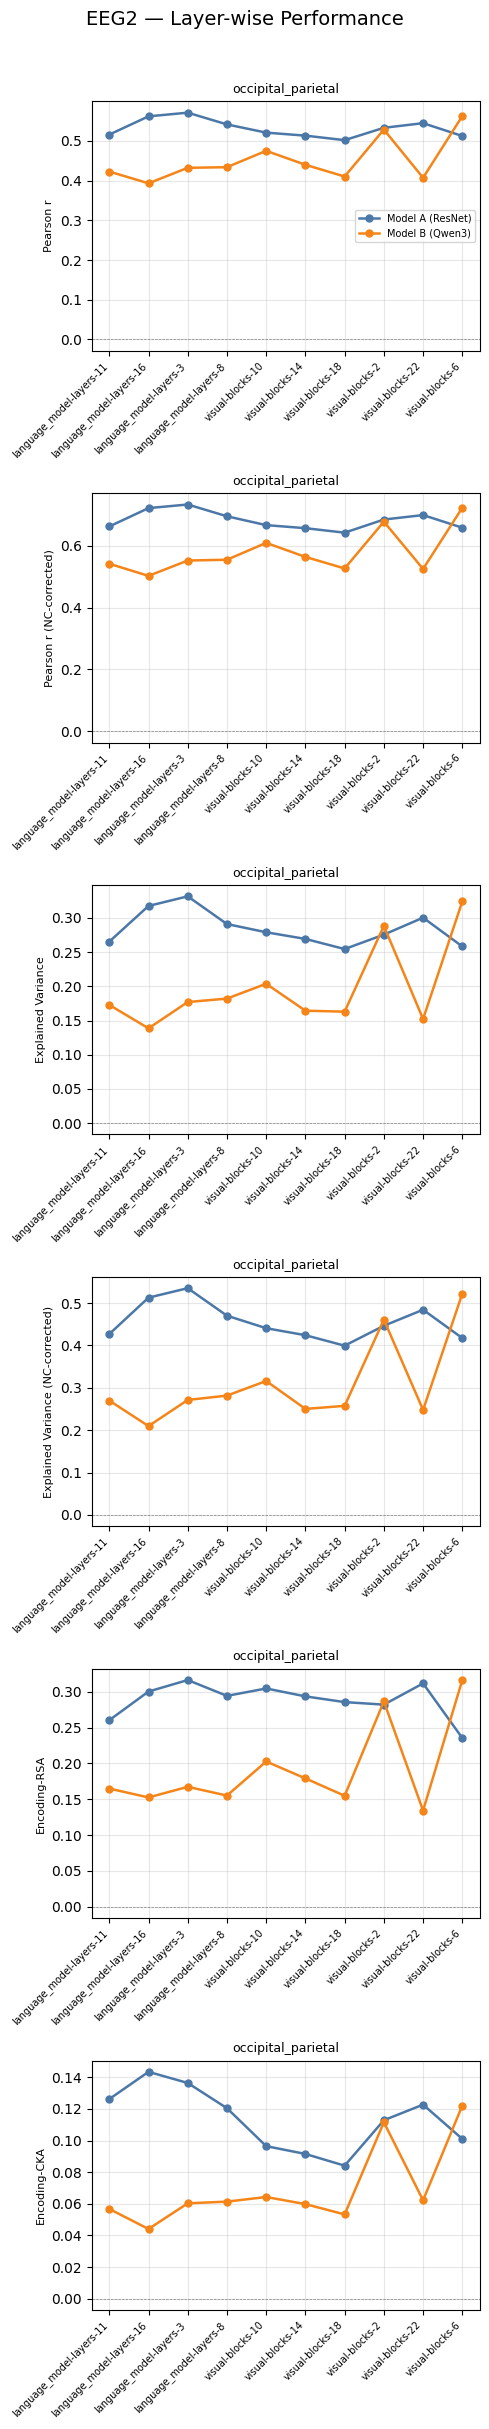

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer3-0,0.571,0.733,0.331,0.535,0.316,0.136
1,EEG2,Model B (Qwen3),occipital_parietal,visual-blocks-6,0.562,0.723,0.324,0.522,0.316,0.122


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,0.535,0.522,0.136,0.122,0.316,0.316,0.733,0.723


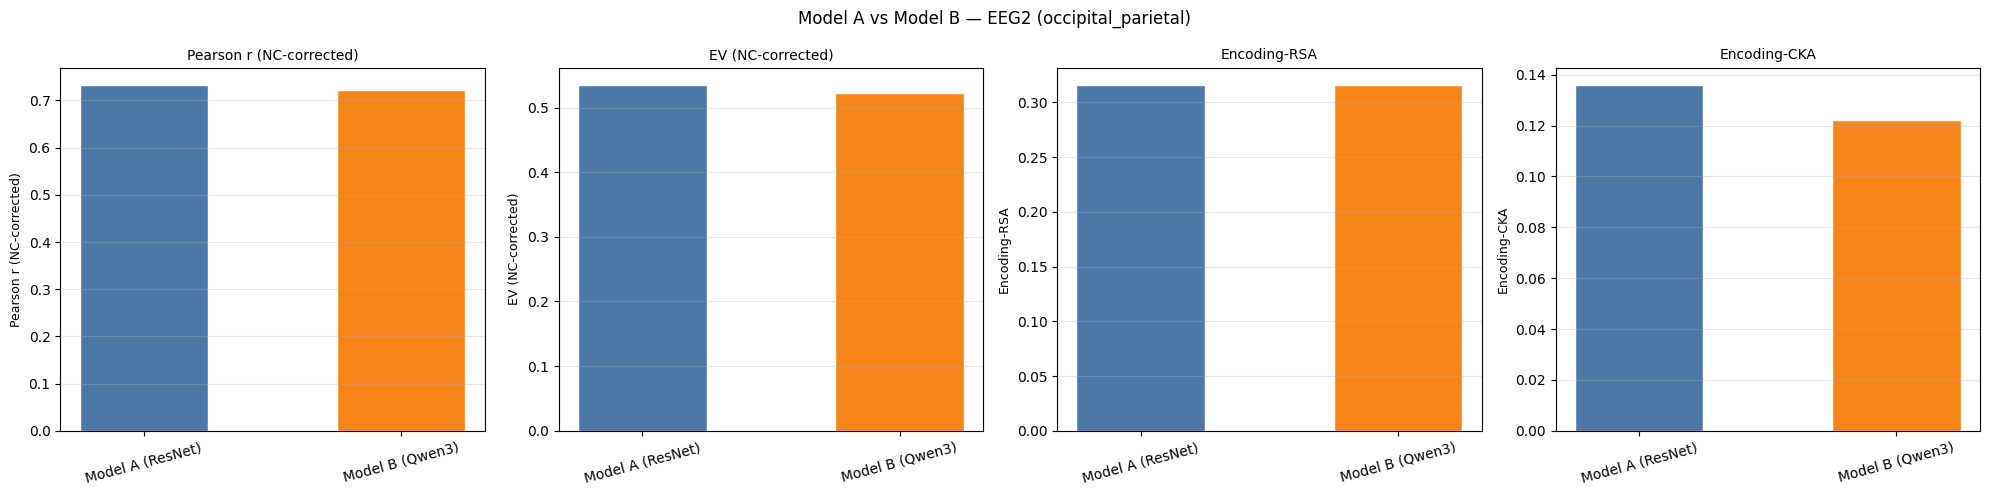


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [3]:
### EEG, 100ms, CUDA, FULL, N_TRAIN = 7500

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42, alpha_grid=None, **kwargs):
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32)).to(DEVICE)
    mean  = Xtr_t.mean(0, keepdim=True)
    std   = Xtr_t.std(0, keepdim=True).clamp(min=1e-8)
    Xtr_t = (Xtr_t - mean) / std
    Xvl_t = (torch.from_numpy(Xvl.astype(np.float32)).to(DEVICE) - mean) / std

    # ─── CENTER Y ───
    Ytr_t  = torch.from_numpy(Ytr.astype(np.float32)).to(DEVICE)
    y_mean = Ytr_t.mean(0, keepdim=True)             # (1, C)
    Ytr_c  = Ytr_t - y_mean                           # centered for fitting
    # ────────────────

    N = Xtr_t.shape[0]
    K  = Xtr_t @ Xtr_t.T
    Kv = Xvl_t @ Xtr_t.T

    eigvals, U = torch.linalg.eigh(K)
    UtY = U.T @ Ytr_c                                 # use centered Y
    KvU = Kv @ U

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0 = time.time()
        inv = 1.0 / (eigvals + float(alpha))
        Yv_hat = (KvU * inv) @ UtY + y_mean           # ADD MEAN BACK
        score = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat.cpu().numpy())))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    del Xtr_t, Xvl_t, Ytr_t, Ytr_c, K, Kv, eigvals, U, UtY, KvU
    torch.cuda.empty_cache()

    # Refit on full train
    X_full_t = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f   = X_full_t.mean(0, keepdim=True)
    std_f    = X_full_t.std(0, keepdim=True).clamp(min=1e-8)
    X_full_t = (X_full_t - mean_f) / std_f

    Y_full_t  = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f  = Y_full_t.mean(0, keepdim=True)        # (1, C) — full-train Y mean
    Y_full_c  = Y_full_t - y_mean_f

    N_full = X_full_t.shape[0]
    gamma  = torch.linalg.solve(
        X_full_t @ X_full_t.T + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,                                     # centered
    )
    beta = X_full_t.T @ gamma

    del X_full_t, Y_full_t, Y_full_c, gamma
    torch.cuda.empty_cache()

    return beta, mean_f, std_f, y_mean_f, best_alpha   # ← NOW RETURNS y_mean_f TOO


def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()    # ← ADD MEAN BACK

    nc_01 = nc_flat / 100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    return summarise_metrics(r, r_nc, ev, ev_nc, nc_flat), Y_pred

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)

                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [4]:
df_results.to_csv("cuda_eeg_100ms_full.csv", index=False)


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=300 ms (index 30) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+00  val_r=0.0158 ◀ best so far  (0.07s)
        α=3.2e+00  val_r=0.0159 ◀ best so far  (0.00s)
        α=1.0e+01  val_r=0.0162 ◀ best so far  (0.00s)
        α=3.2e+01  val_r=0.0170 ◀ best so far  (0.00s)
        α=1.0e+02  val_r=0.0189 ◀ best so far  (0.00s)
        α=3.2e+02  val_r=0.0223 ◀ best so far  (0.00s)
        α=1.0e+03  val_r=0.0265 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.0306 ◀ best so far  (0.00s)
        α=1.0e+04  val_r=0.0378 ◀ best so far  (0.00s)
        α=3.2e+04  val_r=0.0506 ◀ best so far  (0.00s)
        α=1.0e+05  val_r=0.0677 ◀ best so far  (0.00s)
        α=3.2e+05  val_r=0.0880 ◀ best so f

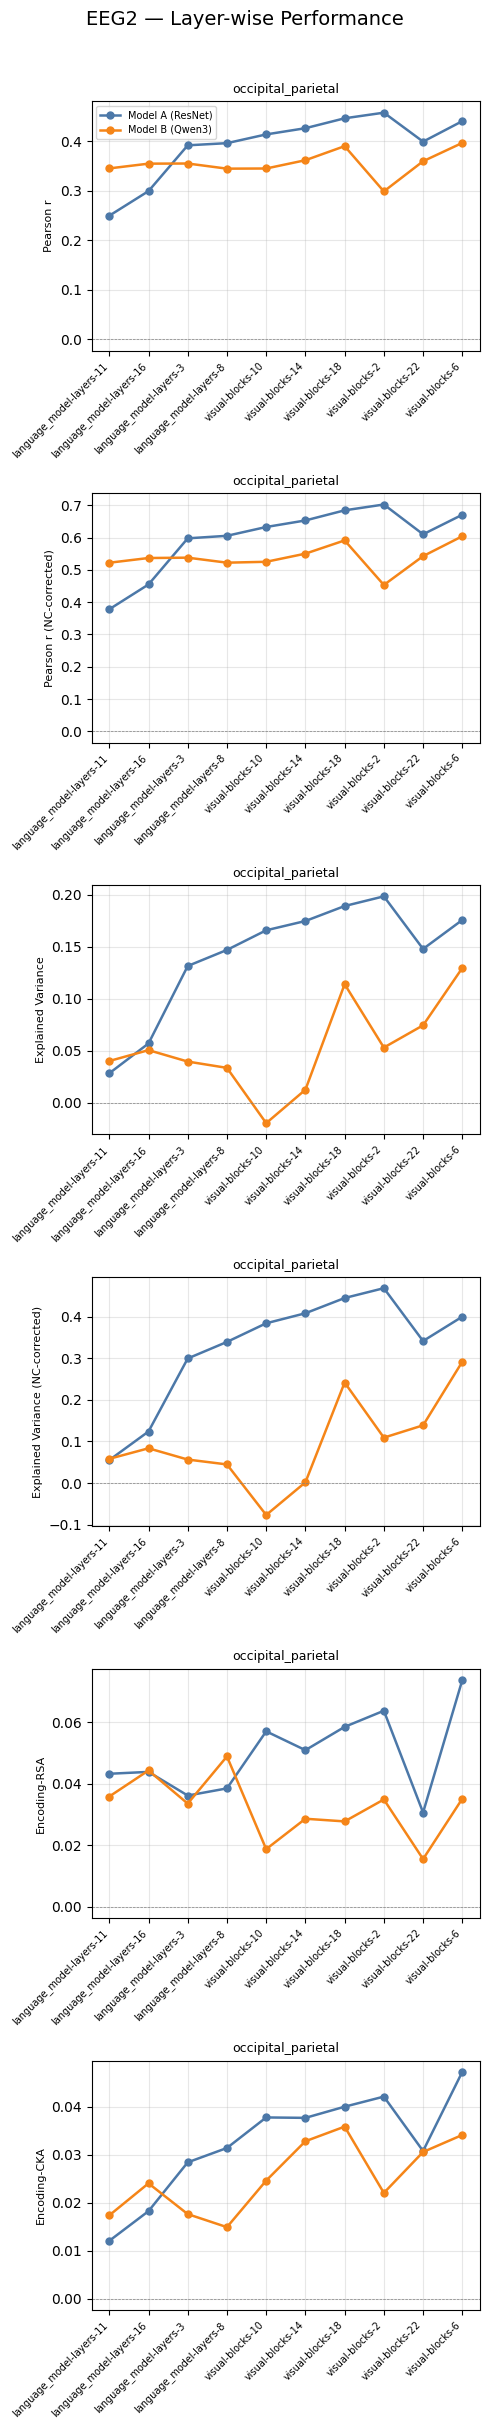

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer3-30,0.458,0.702,0.199,0.468,0.064,0.042
1,EEG2,Model B (Qwen3),occipital_parietal,visual-blocks-6,0.397,0.604,0.130,0.292,0.035,0.034


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,0.468,0.292,0.042,0.034,0.064,0.035,0.702,0.604


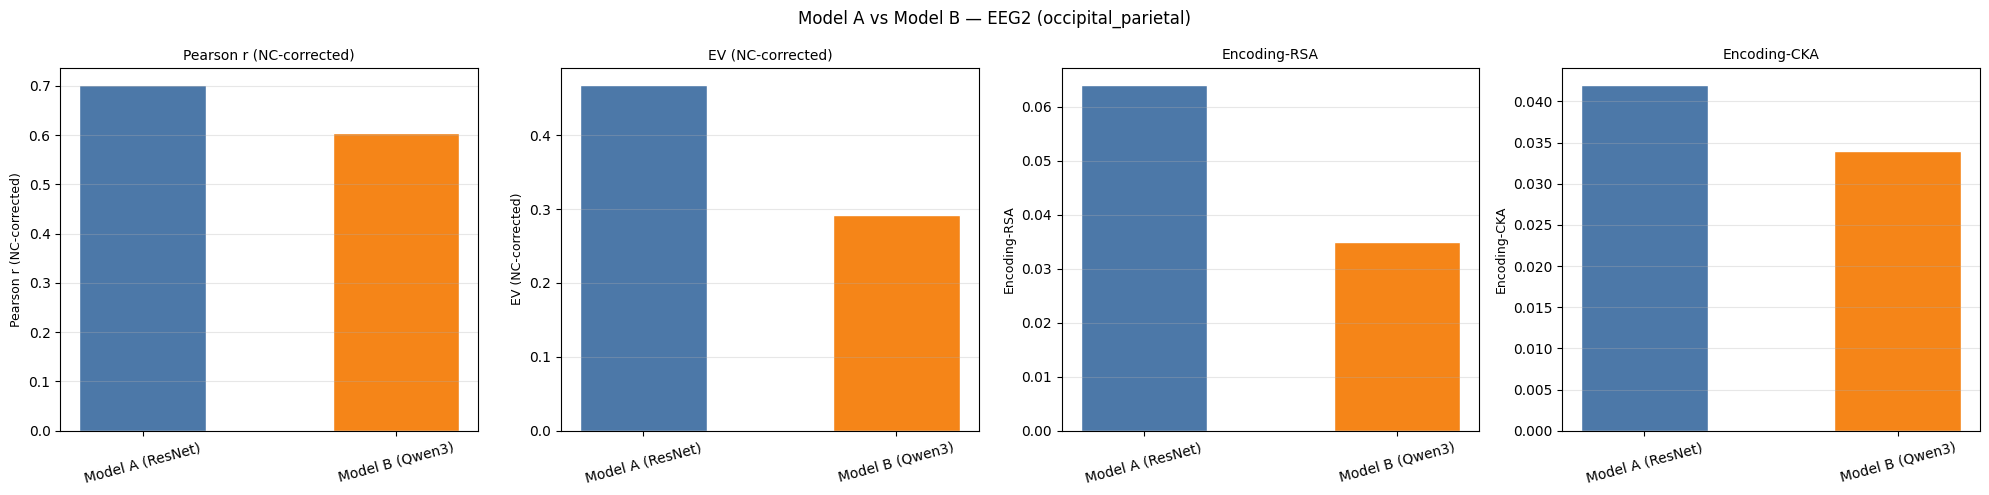


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [5]:
### EEG, 300ms, CUDA, FULL, N_TRAIN = 7500

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 300          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42, alpha_grid=None, **kwargs):
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32)).to(DEVICE)
    mean  = Xtr_t.mean(0, keepdim=True)
    std   = Xtr_t.std(0, keepdim=True).clamp(min=1e-8)
    Xtr_t = (Xtr_t - mean) / std
    Xvl_t = (torch.from_numpy(Xvl.astype(np.float32)).to(DEVICE) - mean) / std

    # ─── CENTER Y ───
    Ytr_t  = torch.from_numpy(Ytr.astype(np.float32)).to(DEVICE)
    y_mean = Ytr_t.mean(0, keepdim=True)             # (1, C)
    Ytr_c  = Ytr_t - y_mean                           # centered for fitting
    # ────────────────

    N = Xtr_t.shape[0]
    K  = Xtr_t @ Xtr_t.T
    Kv = Xvl_t @ Xtr_t.T

    eigvals, U = torch.linalg.eigh(K)
    UtY = U.T @ Ytr_c                                 # use centered Y
    KvU = Kv @ U

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0 = time.time()
        inv = 1.0 / (eigvals + float(alpha))
        Yv_hat = (KvU * inv) @ UtY + y_mean           # ADD MEAN BACK
        score = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat.cpu().numpy())))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    del Xtr_t, Xvl_t, Ytr_t, Ytr_c, K, Kv, eigvals, U, UtY, KvU
    torch.cuda.empty_cache()

    # Refit on full train
    X_full_t = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f   = X_full_t.mean(0, keepdim=True)
    std_f    = X_full_t.std(0, keepdim=True).clamp(min=1e-8)
    X_full_t = (X_full_t - mean_f) / std_f

    Y_full_t  = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f  = Y_full_t.mean(0, keepdim=True)        # (1, C) — full-train Y mean
    Y_full_c  = Y_full_t - y_mean_f

    N_full = X_full_t.shape[0]
    gamma  = torch.linalg.solve(
        X_full_t @ X_full_t.T + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,                                     # centered
    )
    beta = X_full_t.T @ gamma

    del X_full_t, Y_full_t, Y_full_c, gamma
    torch.cuda.empty_cache()

    return beta, mean_f, std_f, y_mean_f, best_alpha   # ← NOW RETURNS y_mean_f TOO


def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()    # ← ADD MEAN BACK

    nc_01 = nc_flat / 100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    return summarise_metrics(r, r_nc, ev, ev_nc, nc_flat), Y_pred

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)

                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [6]:
df_results.to_csv("cuda_eeg_300ms_full.csv", index=False)


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=400 ms (index 40) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
🚀 FULL RUN
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+00  val_r=-0.0102 ◀ best so far  (0.08s)
        α=3.2e+00  val_r=-0.0102  (0.00s)
        α=1.0e+01  val_r=-0.0100 ◀ best so far  (0.00s)
        α=3.2e+01  val_r=-0.0092 ◀ best so far  (0.00s)
        α=1.0e+02  val_r=-0.0068 ◀ best so far  (0.00s)
        α=3.2e+02  val_r=-0.0018 ◀ best so far  (0.00s)
        α=1.0e+03  val_r=0.0060 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.0174 ◀ best so far  (0.00s)
        α=1.0e+04  val_r=0.0363 ◀ best so far  (0.00s)
        α=3.2e+04  val_r=0.0586 ◀ best so far  (0.00s)
        α=1.0e+05  val_r=0.0763 ◀ best so far  (0.00s)
        α=3.2e+05  val_r=0.0872 ◀ best so far  (0.0

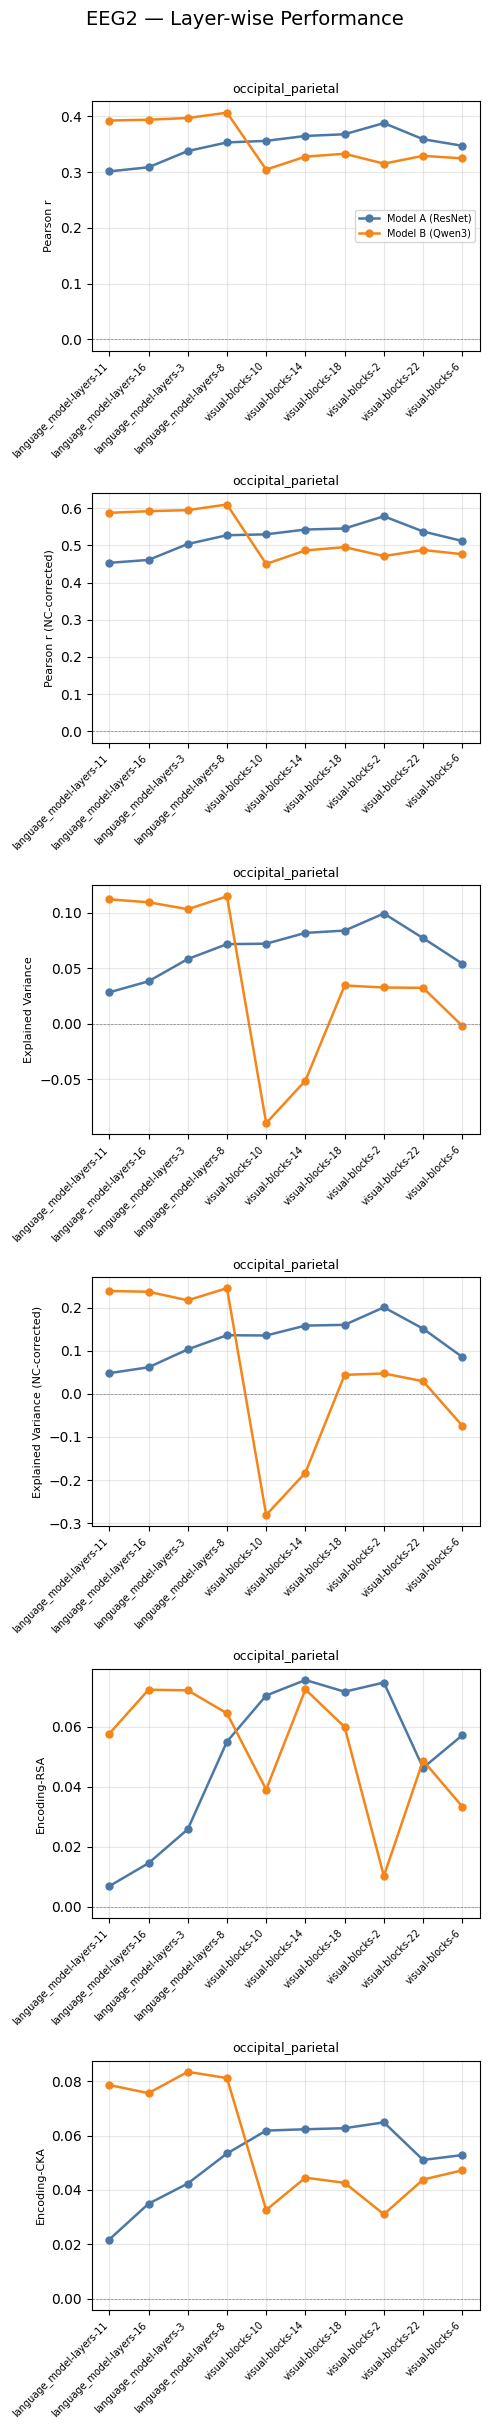

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer3-30,0.388,0.578,0.099,0.200,0.075,0.065
1,EEG2,Model B (Qwen3),occipital_parietal,language_model-layers-8,0.406,0.610,0.115,0.245,0.064,0.081


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,0.2,0.245,0.065,0.081,0.075,0.064,0.578,0.61


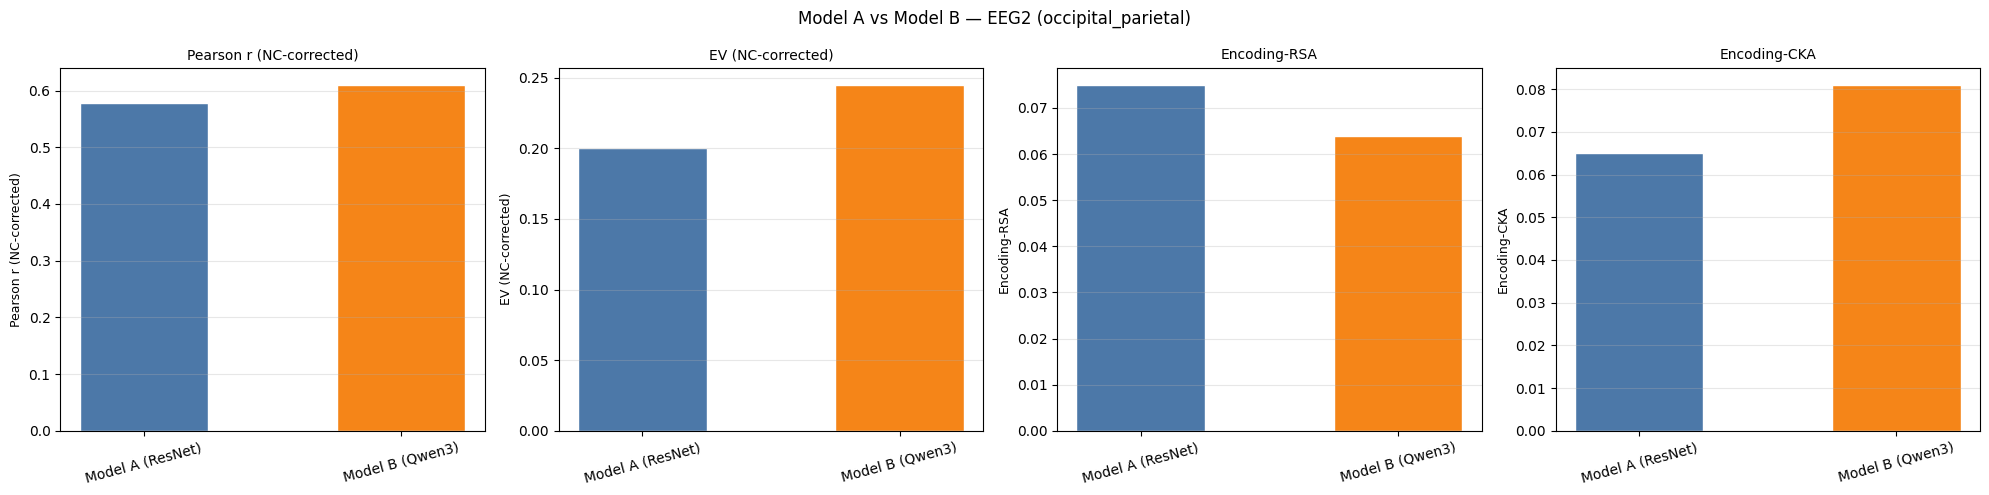


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [3]:
### EEG, 400ms, CUDA, FULL, N_TRAIN = 7500

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 400          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42, alpha_grid=None, **kwargs):
    if alpha_grid is None:
        alpha_grid = np.logspace(0, 7, 15)

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32)).to(DEVICE)
    mean  = Xtr_t.mean(0, keepdim=True)
    std   = Xtr_t.std(0, keepdim=True).clamp(min=1e-8)
    Xtr_t = (Xtr_t - mean) / std
    Xvl_t = (torch.from_numpy(Xvl.astype(np.float32)).to(DEVICE) - mean) / std

    # ─── CENTER Y ───
    Ytr_t  = torch.from_numpy(Ytr.astype(np.float32)).to(DEVICE)
    y_mean = Ytr_t.mean(0, keepdim=True)             # (1, C)
    Ytr_c  = Ytr_t - y_mean                           # centered for fitting
    # ────────────────

    N = Xtr_t.shape[0]
    K  = Xtr_t @ Xtr_t.T
    Kv = Xvl_t @ Xtr_t.T

    eigvals, U = torch.linalg.eigh(K)
    UtY = U.T @ Ytr_c                                 # use centered Y
    KvU = Kv @ U

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0 = time.time()
        inv = 1.0 / (eigvals + float(alpha))
        Yv_hat = (KvU * inv) @ UtY + y_mean           # ADD MEAN BACK
        score = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat.cpu().numpy())))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.2f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    del Xtr_t, Xvl_t, Ytr_t, Ytr_c, K, Kv, eigvals, U, UtY, KvU
    torch.cuda.empty_cache()

    # Refit on full train
    X_full_t = torch.from_numpy(X_train.astype(np.float32)).to(DEVICE)
    mean_f   = X_full_t.mean(0, keepdim=True)
    std_f    = X_full_t.std(0, keepdim=True).clamp(min=1e-8)
    X_full_t = (X_full_t - mean_f) / std_f

    Y_full_t  = torch.from_numpy(Y_train.astype(np.float32)).to(DEVICE)
    y_mean_f  = Y_full_t.mean(0, keepdim=True)        # (1, C) — full-train Y mean
    Y_full_c  = Y_full_t - y_mean_f

    N_full = X_full_t.shape[0]
    gamma  = torch.linalg.solve(
        X_full_t @ X_full_t.T + float(best_alpha) * torch.eye(N_full, device=DEVICE),
        Y_full_c,                                     # centered
    )
    beta = X_full_t.T @ gamma

    del X_full_t, Y_full_t, Y_full_c, gamma
    torch.cuda.empty_cache()

    return beta, mean_f, std_f, y_mean_f, best_alpha   # ← NOW RETURNS y_mean_f TOO


def eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat):
    X_test_t = torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)
    X_test_t = (X_test_t - mean) / std
    with torch.no_grad():
        Y_pred = (X_test_t @ beta + y_mean).cpu().numpy()    # ← ADD MEAN BACK

    nc_01 = nc_flat / 100.0
    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r, nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    return summarise_metrics(r, r_nc, ev, ev_nc, nc_flat), Y_pred

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = False

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.logspace(0, 7, 15)   # 1, ~3, 10, ~32, ..., 1e7

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    beta, mean, std, y_mean, best_alpha = fit_ridge_encoding(X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue
                

                metrics, Y_pred = eval_encoding(beta, mean, std, y_mean, X_test, Y_test, nc_flat)

                
                # ─── DIAGNOSTIC ───
                print(f"        Y_test  mean={Y_test.mean():.3f}  std={Y_test.std():.3f}")
                print(f"        Y_pred  mean={Y_pred.mean():.3f}  std={Y_pred.std():.3f}")
                print(f"        Y_train mean={Y_train.mean():.3f}  std={Y_train.std():.3f}")
                print(f"        Pearson r (mean over channels): {pearson_r_per_unit(Y_test, Y_pred).mean():.3f}")
                print(f"        EV       (mean over channels): {explained_variance_per_unit(Y_test, Y_pred).mean():.3f}")
                # ─────────────────
                
                                
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [4]:
df_results.to_csv("cuda_eeg_400ms_full.csv", index=False)


In [6]:
print("dtype:", df_results["encoding_rsa"].dtype)
print("null count:", df_results["encoding_rsa"].isna().sum(), "/", len(df_results))
print("unique values:", df_results["encoding_rsa"].unique()[:10])
print(df_results[["model", "layer", "encoding_rsa", "encoding_cka"]].head(5))

dtype: float64
null count: 20 / 20
unique values: [nan]
              model               layer  encoding_rsa  encoding_cka
0  Model A (ResNet)   features/layer1-0           NaN      0.126196
1  Model A (ResNet)   features/layer2-0           NaN      0.143429
2  Model A (ResNet)   features/layer3-0           NaN      0.136392
3  Model A (ResNet)  features/layer3-10           NaN      0.120448
4  Model A (ResNet)  features/layer3-15           NaN      0.096449


In [7]:
rng = np.random.default_rng(0)
A = rng.standard_normal((50, 10))
B = A + 0.1 * rng.standard_normal((50, 10))
print("RSA:", rsa_fn(A, B))   # expect ~0.9+

NameError: name 'pdist' is not defined

In [3]:
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm



warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓


In [4]:

print("Model A (ResNet) layers:")
with h5py.File(path_a_things, "r") as f:
    for layer in list_h5_layers(path_a_things):
        shape = f[layer].shape
        d = int(np.prod(shape[1:]))  # everything except the stimulus axis
        gram_gb = (d * d * 4) / 1e9   # float32 (d,d) matrix in GB
        print(f"  {layer:<35} shape={shape}  d={d:>8,}  XtX={gram_gb:6.2f} GB")

print("\nModel B (Qwen3) layers:")
with h5py.File(path_b_things, "r") as f:
    for layer in list_h5_layers(path_b_things):
        shape = f[layer].shape
        d = int(np.prod(shape[1:]))
        gram_gb = (d * d * 4) / 1e9
        print(f"  {layer:<35} shape={shape}  d={d:>8,}  XtX={gram_gb:6.2f} GB")

Model A (ResNet) layers:
  features/layer1-0                   shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer2-0                   shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-0                   shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-10                  shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-15                  shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-20                  shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-25                  shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-30                  shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer3-5                   shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  features/layer4-1                   shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB

Model B (Qwen3) layers:
  features/language_model-layers-11   shape=(26107, 30000)  d=  30,000  XtX=  3.60 GB
  fe

In [ ]:
### EEG, 100ms, ADAM, N_TRAIN = 2500

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac:   float = 0.15,
    seed:       int   = 42,
    alpha_grid: np.ndarray = None,
    n_epochs:   int   = 300,
    batch_size: int   = 256,
    lr:         float = 1e-2,
) -> tuple:
    if alpha_grid is None:
        alpha_grid = WD_GRID

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    d = Xtr_s.shape[1]
    C = Ytr.shape[1]

    # Move validation data to GPU once
    Xvl_t = torch.tensor(Xvl_s, dtype=torch.float32).to(DEVICE)

    best_wd, best_score = alpha_grid[0], -np.inf
    for wd in alpha_grid:
        t0 = time.time()
        torch.manual_seed(seed)
        model = nn.Linear(d, C).to(DEVICE)
        opt   = torch.optim.AdamW(
            [
                {"params": [model.weight], "weight_decay": float(wd)},
                {"params": [model.bias],   "weight_decay": 0.0},
            ],
            lr=lr,
        )

        Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32).to(DEVICE)
        Ytr_t = torch.tensor(Ytr,   dtype=torch.float32).to(DEVICE)
        loader = DataLoader(TensorDataset(Xtr_t, Ytr_t),
                            batch_size=batch_size, shuffle=True)

        for _ in range(n_epochs):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                nn.functional.mse_loss(model(xb), yb).backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            Yv_hat = model(Xvl_t).cpu().numpy()

        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        wd={wd:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_wd = score, wd

    # Retrain on full training set with best weight decay
    scaler_full = StandardScaler()
    X_full_s    = scaler_full.fit_transform(X_train)
    torch.manual_seed(seed)
    model_final = nn.Linear(d, C).to(DEVICE)
    opt_final   = torch.optim.AdamW(
        [
            {"params": [model_final.weight], "weight_decay": float(best_wd)},
            {"params": [model_final.bias],   "weight_decay": 0.0},
        ],
        lr=lr,
    )
    Xfull_t     = torch.tensor(X_full_s, dtype=torch.float32).to(DEVICE)
    Yfull_t     = torch.tensor(Y_train,  dtype=torch.float32).to(DEVICE)
    loader_full = DataLoader(TensorDataset(Xfull_t, Yfull_t),
                             batch_size=batch_size, shuffle=True)

    for _ in range(n_epochs):
        model_final.train()
        for xb, yb in loader_full:
            opt_final.zero_grad()
            nn.functional.mse_loss(model_final(xb), yb).backward()
            opt_final.step()

    model_final.eval()
    return model_final, scaler_full, best_wd


def eval_encoding(model, scaler, X_test, Y_test, nc_flat):
    X_test_s = scaler.transform(X_test)
    X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        Y_pred = model(X_test_t).cpu().numpy()

    nc_01  = nc_flat / 100.0
    r      = pearson_r_per_unit(Y_test, Y_pred)
    ev     = explained_variance_per_unit(Y_test, Y_pred)
    r_nc   = nc_correct_r(r,  nc_01)
    ev_nc  = nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = WD_GRID

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = WD_GRID

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    ridge, scaler, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                metrics, Y_pred = eval_encoding(ridge, scaler, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        wd=1.0e-03  val_r=0.0420 ◀ best so far  (23.1s)
        wd=3.2e-03  val_r=0.0360  (22.8s)
        wd=1.0e-02  val_r=0.0443 ◀ best so far  (22.8s)
        wd=3.2e-02  val_r=0.0459 ◀ best so far  (22.2s)
        wd=1.0e-01  val_r=0.0468 ◀ best so far  (23.0s)
        wd=3.2e-01  val_r=0.0688 ◀ best so far  (23.1s)
        wd=1.0e+00  val_r=0.0794 ◀ best so far  (23.0s)
        wd=3.2e+00  val_r=0.0688  (22.7s)
        wd=1.0e+01  val_r=0.0807 ◀ best so far  (23.1s)
        wd=3.2e+01  val_r=0.0992 ◀ best so far  (23.1s)
        wd=1.0e+02  val_r=0.0805  (23.5s)
        wd=3.2e+02  val_r=nan  (23.

In [4]:
### EEG, 100ms, ADAM, N_TRAIN = 2500

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Weight-decay grid (L2 regularization strength for Adam)
WD_GRID = np.logspace(-3, 3, 13)   # 0.001 … 1000

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac:   float = 0.15,
    seed:       int   = 42,
    alpha_grid: np.ndarray = None,
    n_epochs:   int   = 300,
    batch_size: int   = 256,
    lr:         float = 1e-2,
) -> tuple:
    if alpha_grid is None:
        alpha_grid = WD_GRID

    rng     = np.random.default_rng(seed)
    n       = X_train.shape[0]
    n_val   = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    d = Xtr_s.shape[1]
    C = Ytr.shape[1]

    # Move validation data to GPU once
    Xvl_t = torch.tensor(Xvl_s, dtype=torch.float32).to(DEVICE)

    best_wd, best_score = alpha_grid[0], -np.inf
    for wd in alpha_grid:
        t0 = time.time()
        torch.manual_seed(seed)
        model = nn.Linear(d, C).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=float(wd))

        Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32).to(DEVICE)
        Ytr_t = torch.tensor(Ytr,   dtype=torch.float32).to(DEVICE)
        loader = DataLoader(TensorDataset(Xtr_t, Ytr_t),
                            batch_size=batch_size, shuffle=True)

        for _ in range(n_epochs):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                nn.functional.mse_loss(model(xb), yb).backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            Yv_hat = model(Xvl_t).cpu().numpy()

        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        wd={wd:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_wd = score, wd

    # Retrain on full training set with best weight decay
    scaler_full = StandardScaler()
    X_full_s    = scaler_full.fit_transform(X_train)
    torch.manual_seed(seed)
    model_final = nn.Linear(d, C).to(DEVICE)
    opt_final   = torch.optim.Adam(model_final.parameters(), lr=lr, weight_decay=float(best_wd))
    Xfull_t     = torch.tensor(X_full_s, dtype=torch.float32).to(DEVICE)
    Yfull_t     = torch.tensor(Y_train,  dtype=torch.float32).to(DEVICE)
    loader_full = DataLoader(TensorDataset(Xfull_t, Yfull_t),
                             batch_size=batch_size, shuffle=True)

    for _ in range(n_epochs):
        model_final.train()
        for xb, yb in loader_full:
            opt_final.zero_grad()
            nn.functional.mse_loss(model_final(xb), yb).backward()
            opt_final.step()

    model_final.eval()
    return model_final, scaler_full, best_wd


def eval_encoding(model, scaler, X_test, Y_test, nc_flat):
    X_test_s = scaler.transform(X_test)
    X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        Y_pred = model(X_test_t).cpu().numpy()

    nc_01  = nc_flat / 100.0
    r      = pearson_r_per_unit(Y_test, Y_pred)
    ev     = explained_variance_per_unit(Y_test, Y_pred)
    r_nc   = nc_correct_r(r,  nc_01)
    ev_nc  = nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 2500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = WD_GRID

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = WD_GRID

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    ridge, scaler, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                metrics, Y_pred = eval_encoding(ridge, scaler, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


Using device: cuda
EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        wd=1.0e-03  val_r=0.0381 ◀ best so far  (9.5s)
        wd=3.2e-03  val_r=0.0432 ◀ best so far  (7.9s)
        wd=1.0e-02  val_r=0.0276  (8.5s)
        wd=3.2e-02  val_r=0.0421  (8.6s)
        wd=1.0e-01  val_r=0.0683 ◀ best so far  (8.5s)
        wd=3.2e-01  val_r=0.0706 ◀ best so far  (8.4s)
        wd=1.0e+00  val_r=0.0550  (8.3s)
        wd=3.2e+00  val_r=0.0580  (8.4s)
        wd=1.0e+01  val_r=0.0843 ◀ best so far  (7.7s)
        wd=3.2e+01  val_r=0.0624  (7.6s)
        wd=1.0e+02  val_r=0.0796  (7.6s)
        wd=3.2e+02  val_r=0.0639  (7.6s)
        wd=1.0e+03  val_r=0.0449  (8.1s)
    [ 

KeyboardInterrupt: 

In [7]:
import h5py

with h5py.File(path_a_things, "r") as f:
    ids_a = f["ids"][:20]

with h5py.File(path_b_things, "r") as f:
    ids_b = f["ids"][:20]

print("Model A:", ids_a)
print("Model B:", ids_b)
print("Same order?", all(a == b for a, b in zip(ids_a, ids_b)))

Model A: [b'aardvark/aardvark_01b.jpg' b'aardvark/aardvark_02s.jpg'
 b'aardvark/aardvark_03s.jpg' b'aardvark/aardvark_04s.jpg'
 b'aardvark/aardvark_05s.jpg' b'aardvark/aardvark_06s.jpg'
 b'aardvark/aardvark_07s.jpg' b'aardvark/aardvark_08s.jpg'
 b'aardvark/aardvark_09s.jpg' b'aardvark/aardvark_10s.jpg'
 b'aardvark/aardvark_11s.jpg' b'aardvark/aardvark_12s.jpg'
 b'aardvark/aardvark_13s.jpg' b'aardvark/aardvark_14s.jpg'
 b'abacus/abacus_01b.jpg' b'abacus/abacus_02s.jpg'
 b'abacus/abacus_03s.jpg' b'abacus/abacus_04s.jpg'
 b'abacus/abacus_05s.jpg' b'abacus/abacus_06s.jpg']
Model B: [b'aardvark/aardvark_01b.jpg' b'aardvark/aardvark_02s.jpg'
 b'aardvark/aardvark_03s.jpg' b'aardvark/aardvark_04s.jpg'
 b'aardvark/aardvark_05s.jpg' b'aardvark/aardvark_06s.jpg'
 b'aardvark/aardvark_07s.jpg' b'aardvark/aardvark_08s.jpg'
 b'aardvark/aardvark_09s.jpg' b'aardvark/aardvark_10s.jpg'
 b'aardvark/aardvark_11s.jpg' b'aardvark/aardvark_12s.jpg'
 b'aardvark/aardvark_13s.jpg' b'aardvark/aardvark_14s.jpg'
 b

EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+05  val_r=0.1417 ◀ best so far  (35.4s)
    [ 1/10] layer1-0                     occipital_parietal  r=0.414  r_nc=0.529  α=1e+05  fit=108.6s   (layer 126.1s | elapsed 2m 06s | ETA 39m 55s)
        α=1.0e+05  val_r=0.1692 ◀ best so far  (40.4s)
    [ 2/10] layer2-0                     occipital_parietal  r=0.490  r_nc=0.628  α=1e+05  fit=101.1s   (layer 105.7s | elapsed 3m 51s | ETA 34m 45s)
        α=1.0e+05  val_r=0.1743 ◀ best so far  (28.8s)
    [ 3/10] layer3-0                     occipital_parietal  r=0.468  r_nc=0.600  α=1e+05  fit=108.5s   (layer 116.9s | elapsed 5m 48s | ETA 32m 55s)
        α=1.0

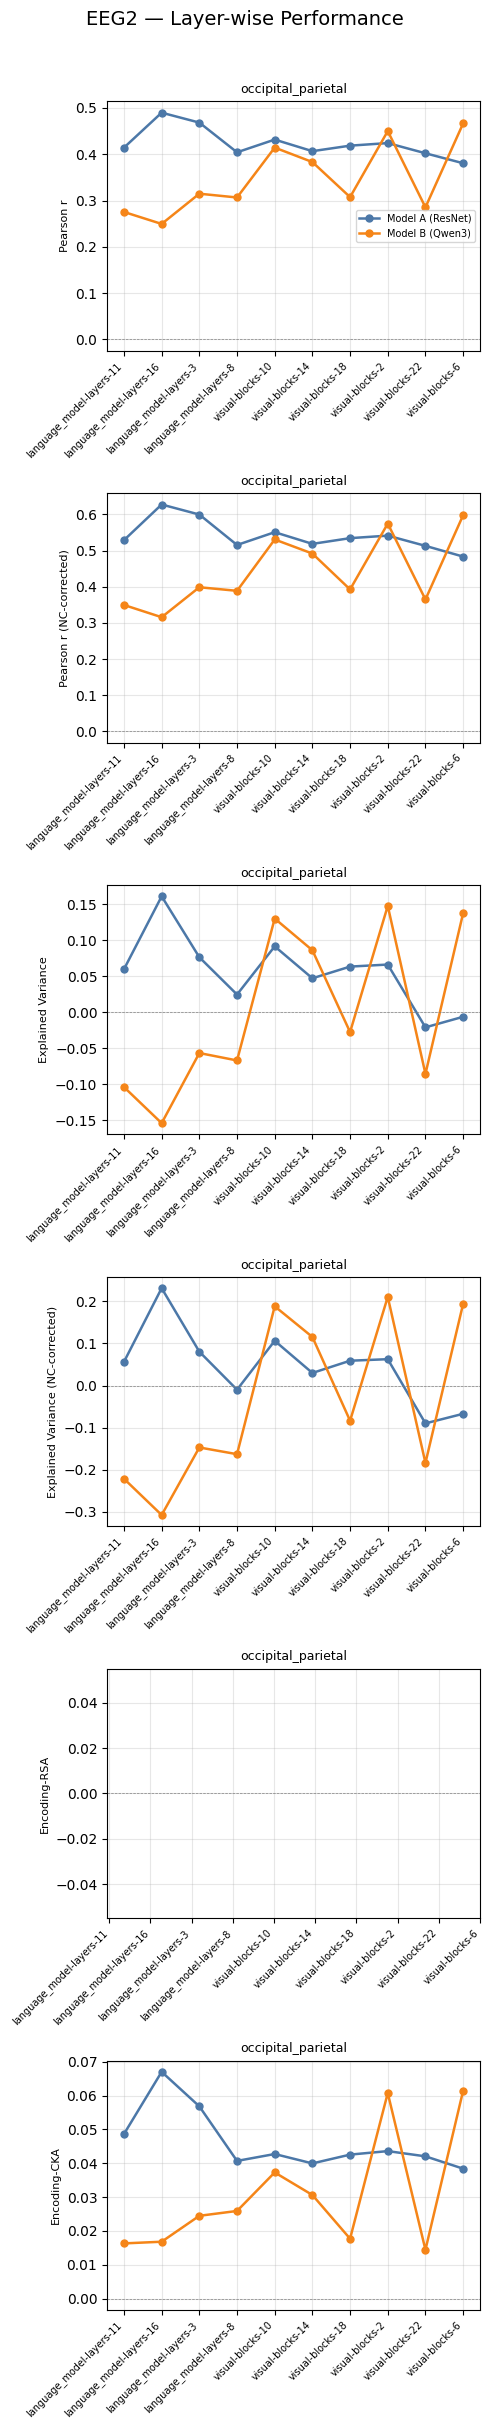

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer2-0,0.490,0.628,0.161,0.231,NaN,0.067
1,EEG2,Model B (Qwen3),occipital_parietal,visual-blocks-6,0.466,0.598,0.138,0.194,NaN,0.061


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,0.231,0.194,0.067,0.061,0.628,0.598


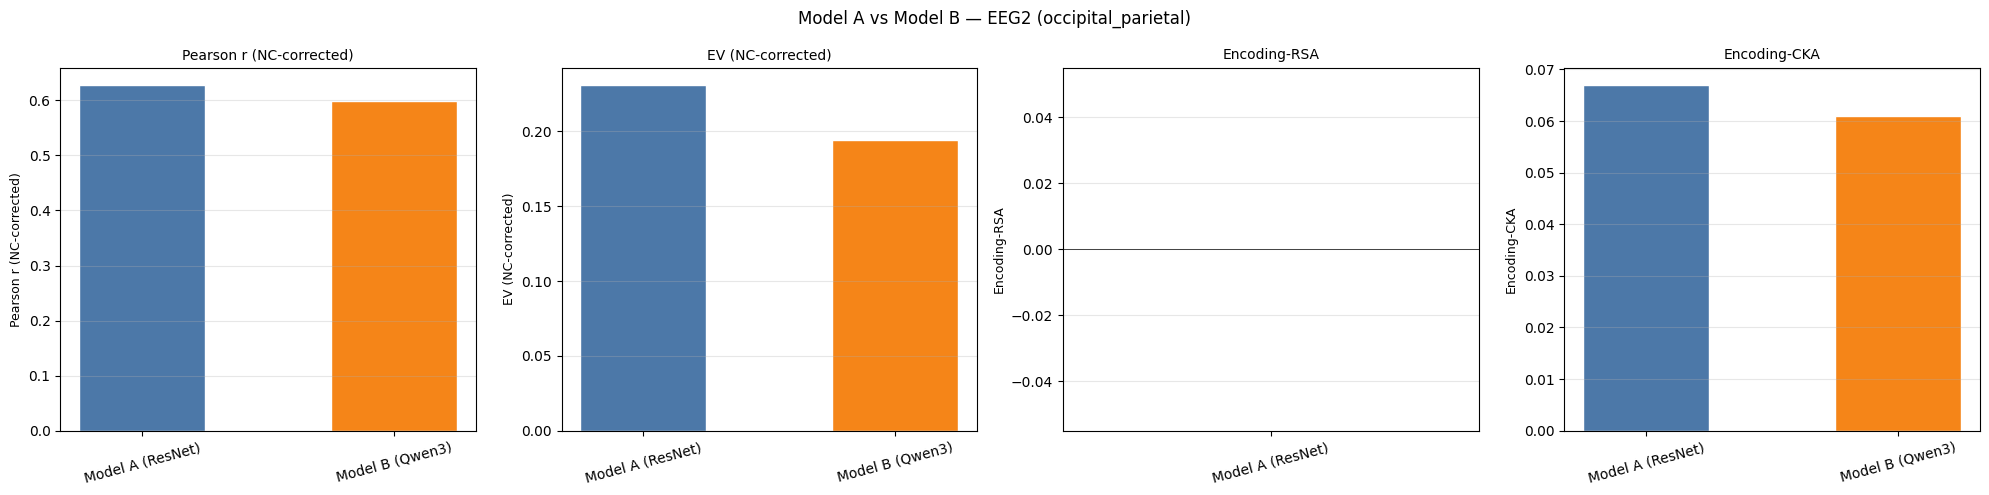


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [4]:
## EEG 100ms gpu

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

ALPHA_GRID = np.logspace(1, 7, 13)

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac: float = 0.15,
    seed: int = 42,
    alpha_grid: np.ndarray = None,
) -> tuple[Ridge, float]:
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID
    rng   = np.random.default_rng(seed)
    n     = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    scaler = StandardScaler(copy=False)
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0    = time.time()
        ridge = Ridge(alpha=alpha, fit_intercept=True, solver="auto")
        ridge.fit(Xtr_s, Ytr)
        Yv_hat = ridge.predict(Xvl_s)
        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    scaler_full = StandardScaler(copy=False)
    X_full_s    = scaler_full.fit_transform(X_train)
    ridge_final = Ridge(alpha=best_alpha, fit_intercept=True, solver="auto")
    ridge_final.fit(X_full_s, Y_train)

    return ridge_final, scaler_full, best_alpha


def eval_encoding(model, scaler, X_test, Y_test, nc_flat):
    Y_pred = model.predict(scaler.transform(X_test))
    nc_01  = nc_flat / 100.0

    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r,  nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.array([1e5])

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = ALPHA_GRID

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    ridge, scaler, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                metrics, Y_pred = eval_encoding(ridge, scaler, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [ ]:
df_results.to_csv("eeg_results_100ms_7500_ridge.csv", index=False)
print("Saved ✓")

EEG2  — sub-01/occipital_parietal | time=100 ms (index 10) | train=(16540, 17), test=(200, 17)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+05  val_r=0.1417 ◀ best so far  (26.0s)
    [ 1/10] layer1-0                     occipital_parietal  r=0.414  r_nc=0.529  α=1e+05  fit=78.5s   (layer 82.4s | elapsed 1m 22s | ETA 26m 05s)
        α=1.0e+05  val_r=0.1692 ◀ best so far  (23.2s)
    [ 2/10] layer2-0                     occipital_parietal  r=0.490  r_nc=0.628  α=1e+05  fit=77.7s   (layer 82.3s | elapsed 2m 44s | ETA 24m 42s)
        α=1.0e+05  val_r=0.1743 ◀ best so far  (28.2s)
    [ 3/10] layer3-0                     occipital_parietal  r=0.468  r_nc=0.600  α=1e+05  fit=80.3s   (layer 88.0s | elapsed 4m 12s | ETA 23m 52s)
        α=1.0e+05  

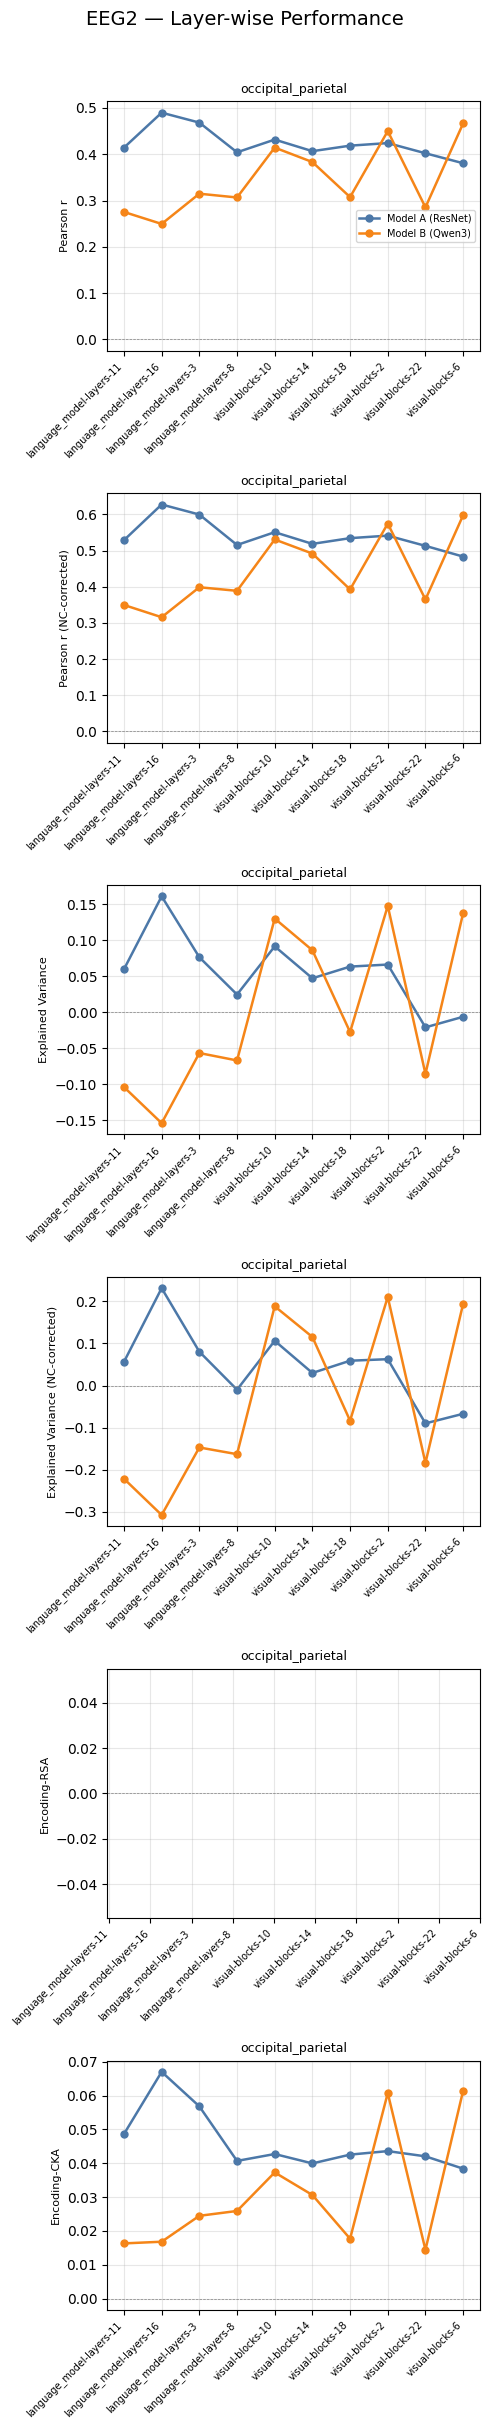

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer2-0,0.490,0.628,0.161,0.231,NaN,0.067
1,EEG2,Model B (Qwen3),occipital_parietal,visual-blocks-6,0.466,0.598,0.138,0.194,NaN,0.061


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,0.231,0.194,0.067,0.061,0.628,0.598


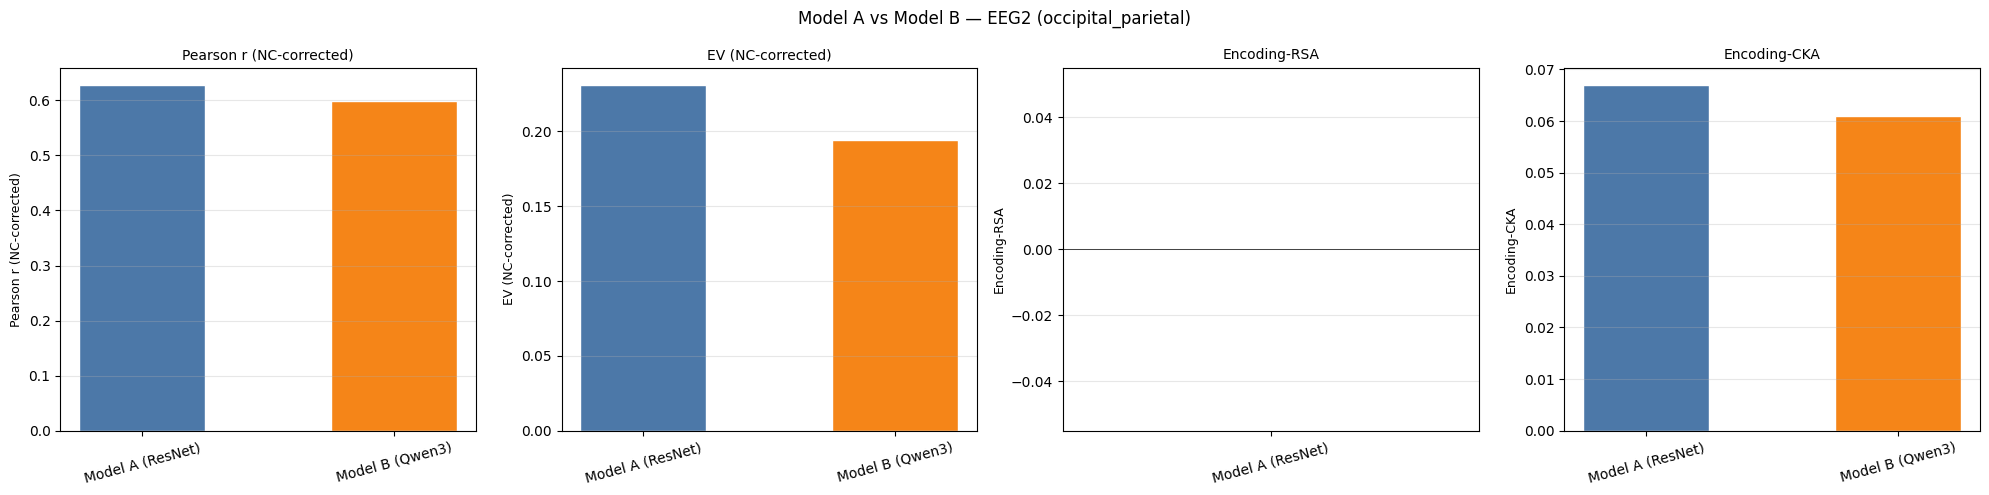


Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.


Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].



In [4]:
### EEG with one time unit at 100ms, NTrain is 7500


# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
EEG_TIME_MS = 100          # target time point in milliseconds

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

EEG_FS = 100  # Hz
t_idx = round(EEG_TIME_MS / 1000 * EEG_FS)   # e.g. 100 ms -> index 10

eeg_neural["train"] = raw_train[:, :, t_idx]  # (stimuli, C)
eeg_neural["test"]  = raw_test[:, :, t_idx]   # (stimuli, C)
eeg_nc_flat         = nc_2d[:, t_idx]          # (C,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | time={EEG_TIME_MS} ms (index {t_idx}) | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

ALPHA_GRID = np.logspace(1, 7, 13)

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac: float = 0.15,
    seed: int = 42,
    alpha_grid: np.ndarray = None,
) -> tuple[Ridge, float]:
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID
    rng   = np.random.default_rng(seed)
    n     = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    scaler = StandardScaler(copy=False)
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0    = time.time()
        ridge = Ridge(alpha=alpha, fit_intercept=True, solver="auto")
        ridge.fit(Xtr_s, Ytr)
        Yv_hat = ridge.predict(Xvl_s)
        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    scaler_full = StandardScaler(copy=False)
    X_full_s    = scaler_full.fit_transform(X_train)
    ridge_final = Ridge(alpha=best_alpha, fit_intercept=True, solver="auto")
    ridge_final.fit(X_full_s, Y_train)

    return ridge_final, scaler_full, best_alpha


def eval_encoding(model, scaler, X_test, Y_test, nc_flat):
    Y_pred = model.predict(scaler.transform(X_test))
    nc_01  = nc_flat / 100.0

    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r,  nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 7500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = np.array([1e5])

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = ALPHA_GRID

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    ridge, scaler, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                metrics, Y_pred = eval_encoding(ridge, scaler, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


In [6]:
### Just EEG with all time units

# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
#               EEG-ONLY VERSION
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"

def list_h5_layers(path: str) -> list[str]:
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    sort_order    = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load EEG neural train/test data
# ─────────────────────────────────────────────────────────────

eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

n_ch, n_tp = raw_train.shape[1], raw_train.shape[2]
eeg_neural["train"] = raw_train.reshape(raw_train.shape[0], -1)
eeg_neural["test"]  = raw_test.reshape(raw_test.shape[0], -1)
eeg_nc_flat         = nc_2d.flatten()                           # (C*T,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

feat_idx_eeg_train = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test  = get_feat_indices(path_a_things, eeg_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    n  = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den

def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot

def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r

def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    return ev / np.clip(nc_ev, 1e-6, None)

def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    mask = nc_flat > 10.0
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":              _m(r),
        "pearsonr_nc":           _m(r_nc),
        "explained_variance":    _m(ev),
        "explained_variance_nc": _m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

ALPHA_GRID = np.logspace(1, 7, 13)

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac: float = 0.15,
    seed: int = 42,
    alpha_grid: np.ndarray = None,
) -> tuple[Ridge, float]:
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID
    rng   = np.random.default_rng(seed)
    n     = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    scaler = StandardScaler(copy=False)
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0    = time.time()
        ridge = Ridge(alpha=alpha, fit_intercept=True, solver="auto")
        ridge.fit(Xtr_s, Ytr)
        Yv_hat = ridge.predict(Xvl_s)
        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    scaler_full = StandardScaler(copy=False)
    X_full_s    = scaler_full.fit_transform(X_train)
    ridge_final = Ridge(alpha=best_alpha, fit_intercept=True, solver="auto")
    ridge_final.fit(X_full_s, Y_train)

    return ridge_final, scaler_full, best_alpha


def eval_encoding(model, scaler, X_test, Y_test, nc_flat):
    Y_pred = model.predict(scaler.transform(X_test))
    nc_01  = nc_flat / 100.0

    r     = pearson_r_per_unit(Y_test, Y_pred)
    ev    = explained_variance_per_unit(Y_test, Y_pred)
    r_nc  = nc_correct_r(r,  nc_01)
    ev_nc = nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)")
    N_TRAIN        = 2500
    N_TEST         = 200
    N_LAYERS       = None
    ALPHA_GRID_RUN = ALPHA_GRID

    eeg_neural_run = {"occipital_parietal": {
                          "train": eeg_neural["train"][:N_TRAIN],
                          "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run  = feat_idx_eeg_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS       = None
    ALPHA_GRID_RUN = ALPHA_GRID

    eeg_neural_run = {"occipital_parietal": eeg_neural}
    eeg_nc_run     = {"occipital_parietal": eeg_nc_flat}

    idx_eeg_train_run = feat_idx_eeg_train
    idx_eeg_test_run  = feat_idx_eeg_test


# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop (EEG only)
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

results = []

datasets_cfg = [
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
]

rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

total_jobs = len(list_h5_layers(path_a_things)) * len(eeg_neural_run) * 2
print(f"Total jobs to run: {total_jobs}  (EEG2 × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)

            target_scores = []
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                try:
                    t0 = time.time()
                    ridge, scaler, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                metrics, Y_pred = eval_encoding(ridge, scaler, X_test, Y_test, nc_flat)

                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":    ds_name,
        "Model":      model_name,
        "Target":     target,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

fig, axes = plt.subplots(1, len(comparison_metrics),
                          figsize=(5 * len(comparison_metrics), 5))
for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby("Model")[metric].mean().reset_index()
    ax.bar(grp["Model"], grp[metric],
           color=["#4c78a8", "#f58518"], edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model A vs Model B — EEG2 (occipital_parietal)", fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
For EEG2, the occipital-parietal grouping is selected because it pools the
electrodes with the highest and most sustained visual evoked responses identified
in Section 1.2, giving a reliable and interpretable summary signal of early-to-mid
visual processing.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best for EEG2?
─────────────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For EEG2, [Model X], layer [Y] achieves the highest NC-corrected Pearson r
  for occipital_parietal (r_nc ≈ ...).  Alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked response;
  [Model X] / [Model Y] achieves higher encoding-RSA at later time points,
  indicating [interpretation].  The vision-language model tends to
  [outperform / underperform] the adversarially-trained CNN, potentially because
  [reason].
""")


EEG2  — sub-01/occipital_parietal | train=(16540, 1360), test=(200, 1360)
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, EEG only (~10 mins)
Total jobs to run: 20  (EEG2 × models × layers × targets)


  Dataset : EEG2
  Targets : ['occipital_parietal']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+01  val_r=0.0102 ◀ best so far  (13.5s)
        α=3.2e+01  val_r=0.0101  (13.8s)
        α=1.0e+02  val_r=0.0098  (12.5s)
        α=3.2e+02  val_r=0.0092  (6.3s)
        α=1.0e+03  val_r=0.0082  (6.8s)
        α=3.2e+03  val_r=0.0087  (7.4s)
        α=1.0e+04  val_r=0.0130 ◀ best so far  (8.4s)
        α=3.2e+04  val_r=0.0198 ◀ best so far  (7.7s)
        α=1.0e+05  val_r=0.0249 ◀ best so far  (8.2s)
        α=3.2e+05  val_r=0.0270 ◀ best so far  (7.8s)
        α=1.0e+06  val_r=0.0279 ◀ best so far  (7.4s)
        α=3.2e+06  val_r=0.0282 ◀ best so far  (7.3s)
        α=1.0e+07  val_r=0.0282 ◀ best so far  (7.3s)
    [ 1/10] la

KeyboardInterrupt: 

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.